<a href="https://colab.research.google.com/github/ss331144/FinalProject-MSFT-AttackAnalysis/blob/main/FinalProject_MicrosoftSecurity_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 **Pip install packages**

In [ ]:
# ------------------------------
# 📦 התקנת חבילות נדרשות (pip)
# ------------------------------
!pip install ydata-profiling # create auto reports
!pip install catboost  # model
!pip install jupyter-dash # create dash with gradio
!pip install optuna # use auto parmeters in model

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.0/679.0 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=54e7f1e9452b89ca576e52be9e185846ca96ae3014a6c15ec3aee8ae8b7bca51
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
     

# 📚 **Library**

In [ ]:
# -----------------------------------------
# 🧮 ספריות עיבוד נתונים וסטטיסטיקה
# -----------------------------------------

import itertools  # creating combinations and permutations
import numpy as np  # mathematical operations with arrays
import os  # working with the file system
import pandas as pd  # managing and analyzing tables
import random  # random operations on data structures
import scipy.stats as stats  # statistical tests and analyses


# -----------------------------------------
# 📊 ספריות ויזואליזציה וגרפים
# -----------------------------------------

import matplotlib.pyplot as plt  # 2D plots and charts
import matplotlib.ticker as mticker  # control tick formatting
import seaborn as sns  # styled statistical plots
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting
from wordcloud import WordCloud  # visual word cloud
from itertools import combinations  # generate combinations

# -----------------------------------------
# 🧠 ספריות למידת מכונה ו-Preprocessing
# -----------------------------------------

from sklearn.compose import ColumnTransformer  # transformation by column type
from sklearn.ensemble import RandomForestClassifier  # random forest for classification
from sklearn.impute import SimpleImputer  # fill missing values
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             mean_absolute_error, mean_squared_error,
                             precision_score, recall_score)  # model performance metrics
from sklearn.model_selection import train_test_split  # split data into train and test sets
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder  # feature encoding and scaling
from sklearn.svm import SVC  # support vector classification
from sklearn.tree import DecisionTreeClassifier, plot_tree  # decision trees and visualization


# -----------------------------------------
# 🚀 CatBoost – אלגוריתם Boosting מתקדם
# -----------------------------------------

from catboost import CatBoostClassifier, CatBoostRegressor  # gradient boosting models with built-in handling of categorical features


# -----------------------------------------
# 📉 יצירת דוח פרופילינג לדאטה
# -----------------------------------------

from ydata_profiling import ProfileReport  # auto report for EDA

# -----------------------------------------
# 🌐 Dash – יצירת ממשקי Web אינטראקטיביים
# -----------------------------------------

import dash  # interactive Dash applications
from dash import dcc, html  # graphical components for Dash
from dash.dependencies import Input, Output, State, ALL  # event handling in Dash

# -----------------------------------------
# 🛜 מודל אתר Html חזותי
# -----------------------------------------
import gradio as gr


# 📊 **Read data ** & explain data


In [ ]:
os.makedirs('data', exist_ok=True)
Files = ['/content/Bulletin Search (2001 - 2008).xlsx',
         '/content/Bulletin Search (2008 - 2017).xlsx']  # רשימה של קבצי האימון
Data_Frame = pd.concat([pd.read_excel(file) for file in Files], ignore_index=True)    # מיזוג קבצי האימון לדאטה סט אחד

# אכיפת סדר על ידי חידוש אינדקסים
Data_Frame = Data_Frame.reset_index(drop=True)

save_dir = '/content/data'
excel_path = os.path.join(save_dir, 'Merged_Bulletin_Data.xlsx')
csv_path = os.path.join(save_dir, 'Merged_Bulletin_Data.csv')

# שמירת הדאטה למבנה אקסל
with pd.ExcelWriter(excel_path) as writer:
    Data_Frame.to_excel(writer, index=False, sheet_name='All Data')
Data_Frame.to_csv(csv_path, index=False)

df = pd.read_excel(excel_path)
print(df.head(4))

  Date\nPosted Bulletin\nId  Bulletin KB  Severity                 Impact  \
0   2008-11-11     MS08-069     955218.0  Critical  Remote Code Execution   
1   2008-11-11     MS08-069     955218.0  Critical  Remote Code Execution   
2   2008-11-11     MS08-069     955218.0  Critical  Remote Code Execution   
3   2008-11-11     MS08-069     955218.0  Critical  Remote Code Execution   

                                               Title  \
0  Vulnerabilities in Microsoft XML Core Services...   
1  Vulnerabilities in Microsoft XML Core Services...   
2  Vulnerabilities in Microsoft XML Core Services...   
3  Vulnerabilities in Microsoft XML Core Services...   

                                    Affected Product  Component KB  \
0              Microsoft Windows 2000 Service Pack 4      955069.0   
1                Microsoft Windows XP Service Pack 2      955069.0   
2      Microsoft Windows XP Professional x64 Edition      955069.0   
3  Microsoft Windows XP Professional x64 Edition ... 

**# Data understanding**

columns names :  Index(['Date\nPosted', 'Bulletin\nId', 'Bulletin KB', 'Severity', 'Impact',
       'Title', 'Affected Product', 'Component KB', 'Affected Component',
       'Impact.1', 'Severity.1', 'Supersedes', 'Reboot', 'CVEs', 'Date Posted',
       'Bulletin Id'],
      dtype='object')
Training Set Shape: (23515, 16)

DataTypes of the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23515 entries, 0 to 23514
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date
Posted         4450 non-null   datetime64[ns]
 1   Bulletin
Id         4450 non-null   object        
 2   Bulletin KB         23470 non-null  float64       
 3   Severity            23499 non-null  object        
 4   Impact              23515 non-null  object        
 5   Title               23515 non-null  object        
 6   Affected Product    23513 non-null  object        
 7   Component KB        23494 non-

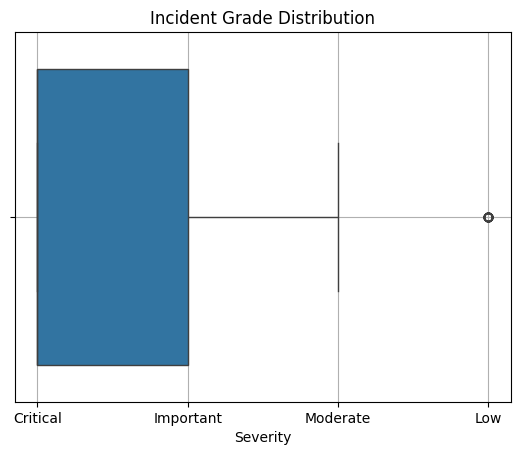

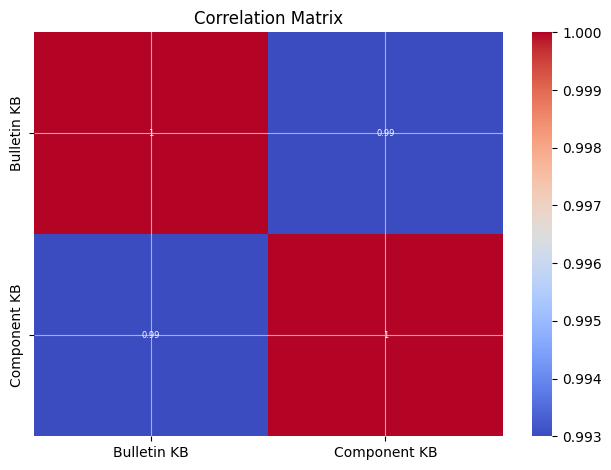

Date Posted range: 2008-11-11 00:00:00 to 2017-03-14 00:00:00

Number of unique values:

Date\nPosted           190
Bulletin\nId           497
Bulletin KB           1355
Severity                 4
Impact                  11
Title                  869
Affected Product       839
Component KB          3577
Affected Component     540
Impact.1                11
Severity.1               4
Supersedes            2096
Reboot                   3
CVEs                  1349
Date Posted            114
Bulletin Id            876
dtype: int64 



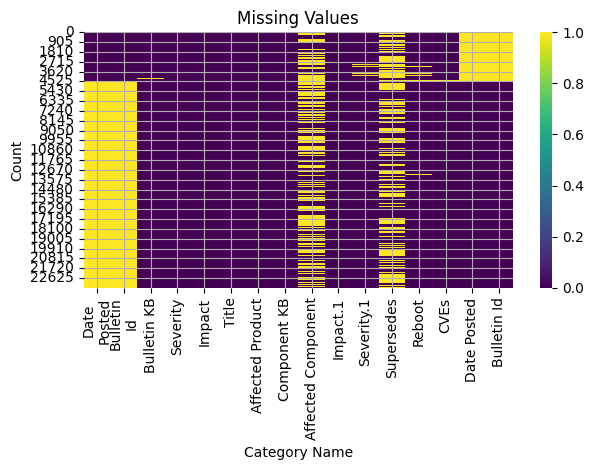

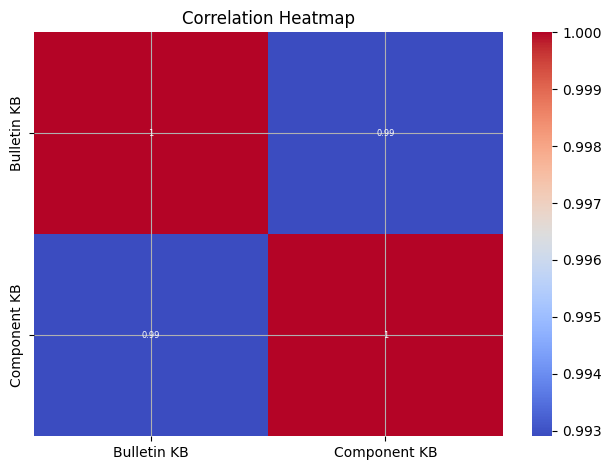

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:01<00:00, 11.35it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

data feature types:
Date\nPosted          datetime64[ns]
Bulletin\nId                  object
Bulletin KB                  float64
Severity                      object
Impact                        object
Title                         object
Affected Product              object
Component KB                 float64
Affected Component            object
Impact.1                      object
Severity.1                    object
Supersedes                    object
Reboot                        object
CVEs                          object
Date Posted           datetime64[ns]
Bulletin Id                   object
dtype: object


In [ ]:
# קריאת קבצי ה-Testing ו-Training
df_all = df.copy()
print(f'columns names :  {df.columns}')
# הצגת המידות של המטריצות
print("=======================================================================================================================")
print(f"Training Set Shape: {df_all.shape}\n")

# הצגת סוגי הנתונים של כל עמודה ב-DataFrame
print("=======================================================================================================================")
print("DataTypes of the dataset:\n")
print(df_all.info(), "\n")


# זיהוי עמודות חסרות
print("=======================================================================================================================")
missing_columns = df_all.isna().sum()
print("Missing columns and count of NaN values:\n", missing_columns[missing_columns > 0], "\n")

# בדיקת דופליקציות בסט
print("=======================================================================================================================")
duplicates = df_all.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}\n")

# הצגת ערכים בעמודות נומריות וקטגוריאליות
print("=======================================================================================================================")
print("Distribution of values in numeric & categorical columns:\n")
print(df_all.describe(include='all'), "\n")


# בדיקת ערכים בעמודה 'Severity'
print("=======================================================================================================================")
sns.boxplot(x=df_all['Severity'].dropna())
plt.title('Incident Grade Distribution')
plt.grid()
plt.show()

# המרת עמודות תאריך לפורמט datetime
print("=======================================================================================================================")
if 'Date Posted' in df_all.columns:
    df_all['Date Posted'] = pd.to_datetime(df_all['Date Posted'], errors='coerce')

# חישוב מטריצת קורלציה עבור הנתונים
print("=======================================================================================================================")
df_numeric = df_all.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix.round(3), annot=True, cbar=True, cmap="coolwarm", annot_kws={"size": 6})
plt.title('Correlation Matrix')
plt.grid()
plt.tight_layout()
plt.show()

# בדיקה אם יש תאריכים עתידיים בעמודת Timestamp
print("=======================================================================================================================")
min_timestamp = df_all['Date Posted'].min()
max_timestamp = df_all['Date Posted'].max()
print(f"Date Posted range: {min_timestamp} to {max_timestamp}\n")


# בדיקת ערכים ייחודיים
print("=======================================================================================================================")
print("Number of unique values:\n")
print(df_all.nunique(), "\n")

# גרף חום תרמוגרפי עבור ערכים חסרים
print("=======================================================================================================================")
sns.heatmap(df_all.isnull(), cbar=True, cmap='viridis')
plt.title('Missing Values')
plt.ylabel('Count')
plt.xlabel('Category Name')
plt.grid()
plt.tight_layout()
plt.show()

# המרת משתנים קטגוריאליים לנומריים אם יש
print("=======================================================================================================================")
if 'Category' in df_all.columns:
    df_all['Category'] = df_all['Category'].astype('category').cat.codes

# חישוב מטריצת הקורלציה אחרי המרה לנומרי
print("=======================================================================================================================")
correlation_matrix = df_all.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cbar=True, cmap="coolwarm", annot_kws={"size": 6})
plt.title('Correlation Heatmap')
plt.grid()
plt.tight_layout()
plt.show()

def create_html_report(df):
    profile = ProfileReport(df , title="Profile Report for the Data",explorative=True , progress_bar=True)
    profile.to_file("Profile data.html")
create_html_report(df)
print("=======================================================================================================================")
print(f'data feature types:')
print(df.dtypes)


#  🎨 **Plots**

✅ קודדו עמודות קטגוריאליות.
encode for Severity : 
  'Critical'  ⇒  0
  'Important'  ⇒  1
  'Low'  ⇒  2
  'Moderate'  ⇒  3
  'nan'  ⇒  4
encode for Severity.1 : 
  'Critical'  ⇒  0
  'Important'  ⇒  1
  'Low'  ⇒  2
  'Moderate'  ⇒  3
  'nan'  ⇒  4
encode for Reboot : 
  'Maybe'  ⇒  0
  'No'  ⇒  1
  'Yes'  ⇒  2
  'nan'  ⇒  3
✅ גרף תלת-מימדי עבור Severity, Severity.1, Reboot נוצר בהצלחה.


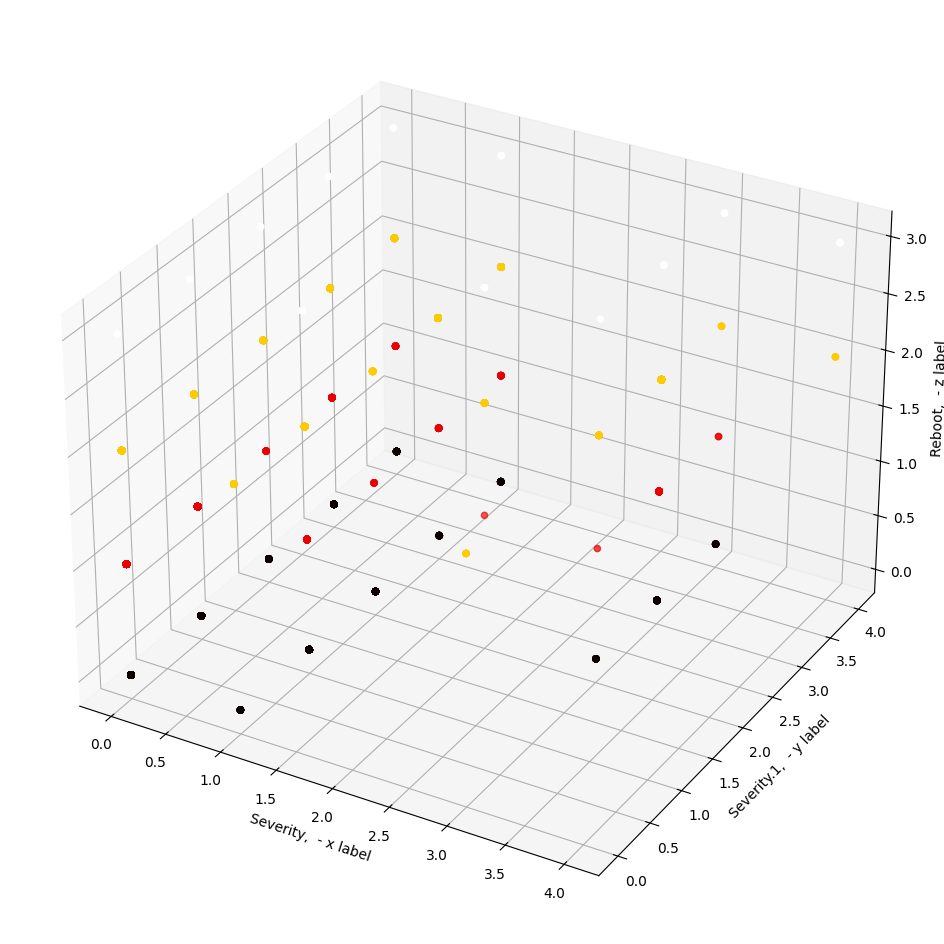

In [ ]:
def encode_columns(df):
    """
    ממירה עמודות קטגוריאליות בדאטה פריים למספרים.

    df: דאטה פריים (DataFrame)
    מחזירה את הדאטה פריים עם עמודות מקודדות.
    """
    df_encoded = df.copy()  # יצירת עותק של הדאטה פריים
    encoders = {}
    encoding_map = {}
    words_encode = {}

    # קידוד עמודות קטגוריאליות
    for col in df_encoded.select_dtypes(include=['object']).columns:
        encoder = LabelEncoder()
        df_encoded[col] = encoder.fit_transform(df_encoded[col])
        encoders[col] = encoder

        # יצירת מילון מיפוי ייחודי לערכים בעמודה זו
        mapping = {label: int(i) for i, label in enumerate(encoder.classes_)}
        encoding_map[col] = mapping
        help_encode = []
        for val, code in mapping.items():
            help_encode.append(f"  '{val}'  ⇒  {code}")
        words_encode[col]=(help_encode)


    print("✅ קודדו עמודות קטגוריאליות.")
    return df_encoded, encoder ,words_encode


def generate_all_3d_plots(df):
    os.makedirs('plot_active', exist_ok=True)
    """
    מייצרת גרפים תלת-מימדיים עבור כל שילוב של שלוש עמודות מתוך דאטה פריים.

    df: דאטה פריים (DataFrame) המכיל את הנתונים.
    """
    # קידוד העמודות לפני יצירת הגרפים
    df_encoded, encoders ,words_encode  = encode_columns(df)

    # בדיקה אם יש לפחות 3 עמודות
    if len(df_encoded.columns) < 3:
        raise ValueError("יש צורך ביותר מ-2 עמודות בדאטה פריים עבור גרף תלת-מימדי.")

    # יצירת כל השילובים האפשריים של 3 עמודות
    col_combinations = combinations(df_encoded.columns, 3)

    for k,val in words_encode.items():
      print(f'encode for {k} : ')
      for i in val:
        print(i)
    # עבור כל שילוב עמודות
    for col1, col2, col3 in col_combinations:
        try:
            # יצירת גרף תלת-מימדי
            fig = plt.figure(figsize=(12, 12))
            ax = fig.add_subplot(111, projection='3d')

            # נתונים עבור כל אחת מהעמודות
            x = df_encoded[col1]
            y = df_encoded[col2]
            z = df_encoded[col3]

            # הצגת הנתונים בגרף תלת-מימדי
            ax.scatter(x, y, z, c=z, cmap='hot')

            # כותרות לצירים
            ax.set_xlabel(f'{col1},  - x label')
            ax.set_ylabel(f'{col2},  - y label')
            ax.set_zlabel(f'{col3},  - z label' )

            # שמירת הגרף בתיקייה
            #plt.savefig(os.path.join('plot_active', f'{col1}_{col2}_{col3}.png'))
            #plt.close()  # סוגר את הגרף כדי למנוע הצגת גרפים מרובים

            print(f"✅ גרף תלת-מימדי עבור {col1}, {col2}, {col3} נוצר בהצלחה.")
            plt.savefig(os.path.join('plot_active', f'{col1}_{col2}_{col3}.png'))
            plt.show()

        except Exception as e:
            print(f"⚠️ לא ניתן ליצור גרף עבור {col1}, {col2}, {col3}. שגיאה: {e}")
            continue  # ממשיך לשילוב הבא אם יש שגיאה



# קריאה לגרפים תלת-מימדיים עבור כל שילוב של 3 עמודות
generate_all_3d_plots(df[['Severity' , 'Severity.1', 'Reboot']])


chi test result : 
   Feature_1           Feature_2          Chi2       p-value
0   Severity        Bulletin\nId  13302.000000  0.000000e+00
1   Severity              Impact  15564.011566  0.000000e+00
2   Severity               Title  64030.362468  0.000000e+00
3   Severity    Affected Product   9510.768606  0.000000e+00
4   Severity  Affected Component  12846.719814  0.000000e+00
5   Severity            Impact.1  11097.938353  0.000000e+00
6   Severity          Severity.1  21057.888081  0.000000e+00
7   Severity          Supersedes  36622.523243  0.000000e+00
8   Severity              Reboot    320.219149  3.789001e-66
9   Severity                CVEs  69731.581869  0.000000e+00
10  Severity         Bulletin Id  38130.000000  0.000000e+00


/tmp/ipython-input-1035017591.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




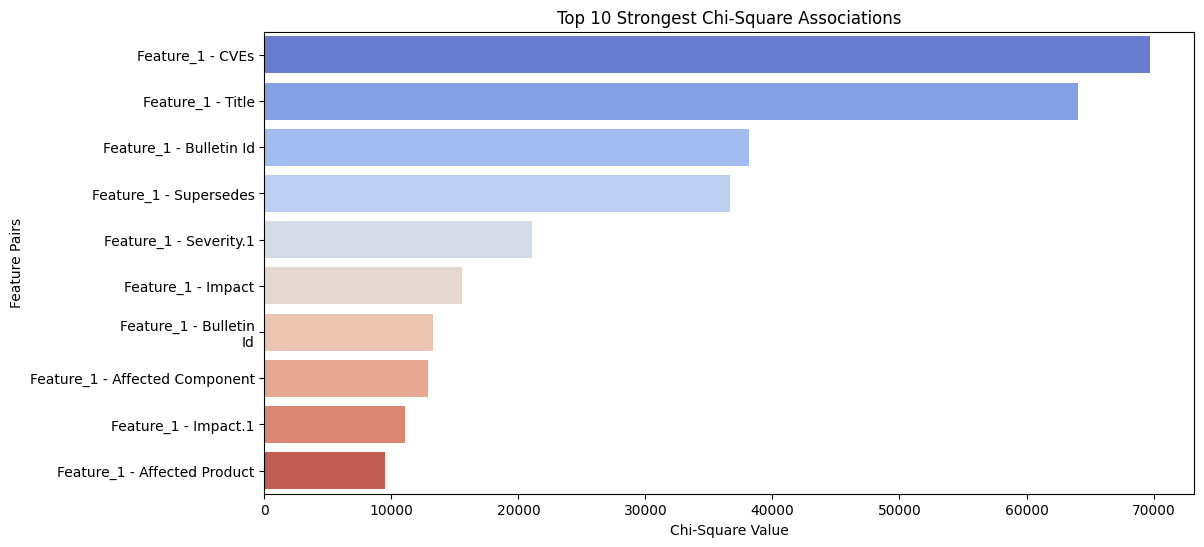

In [ ]:

def plot_chi_square_bar(results_df, top_n=10):
    """
    מצייר גרף עמודות של ערכי חי-בריבוע עבור המשתנים עם הקשרים החזקים ביותר

    Args:
        results_df (pd.DataFrame): DataFrame עם Feature_1, Feature_2 וערכי Chi2
        top_n (int): מספר הצמדים החזקים ביותר להציג

    Returns:
        None
    """
    # מיון לפי הערך הגבוה ביותר של Chi2
    sorted_results = results_df.sort_values(by="Chi2", ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=sorted_results, x="Chi2", y="Feature_1" + " - " + sorted_results["Feature_2"], palette="coolwarm")
    plt.xlabel("Chi-Square Value")
    plt.ylabel("Feature Pairs")
    plt.title(f"Top {top_n} Strongest Chi-Square Associations")
    plt.show()

def chi_square_test(df, target_feature=None):
    """
    מחשבת חי בריבוע לכל זוג משתנים קטגוריאליים ב-DataFrame.

    Args:
        df (pd.DataFrame): מסגרת נתונים עם משתנים קטגוריאליים.
        target_feature (str, optional): משתנה יעד לבדיקה מול כל השאר (אם לא הוגדר, ייבדקו כל הצמדים האפשריים).

    Returns:
        pd.DataFrame: תוצאות מבחן חי בריבוע לכל זוג עמודות.
    """
    # סינון משתנים קטגוריאליים בלבד
    cat_columns = df.select_dtypes(include=['object', 'category']).columns
    results = []

    # אם הוגדר משתנה יעד, בודקים רק מולו
    if target_feature and target_feature in cat_columns:
        columns_to_check = [col for col in cat_columns if col != target_feature]
        pairs = [(target_feature, col) for col in columns_to_check]
    else:
        # בדיקת כל הצמדים האפשריים
        pairs = [(col1, col2) for i, col1 in enumerate(cat_columns) for col2 in cat_columns[i + 1:]]

    # חישוב חי בריבוע לכל צמד משתנים
    for col1, col2 in pairs:
        contingency_table = pd.crosstab(df[col1], df[col2])  # טבלת שכיחות
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)  # חישוב חי בריבוע
        results.append({'Feature_1': col1, 'Feature_2': col2, 'Chi2': chi2, 'p-value': p})

    return pd.DataFrame(results)


df_res=chi_square_test(df,'Severity')
print('chi test result : ')
print(df_res)
#df_res.to_csv('chi Squered values.csv')
try:
  plot_chi_square_bar(df_res)
except Exception as e:
  print(e)

Box Plot Of Severity :


/tmp/ipython-input-484581243.py:27: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



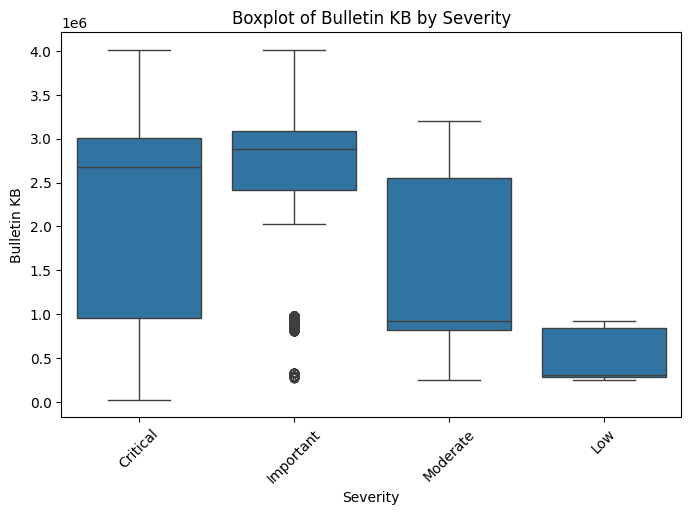

/tmp/ipython-input-484581243.py:27: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



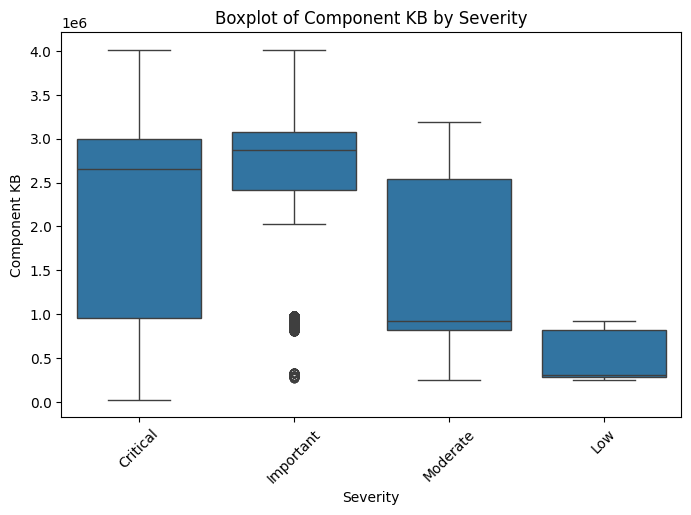

Box Plot Of Impact :


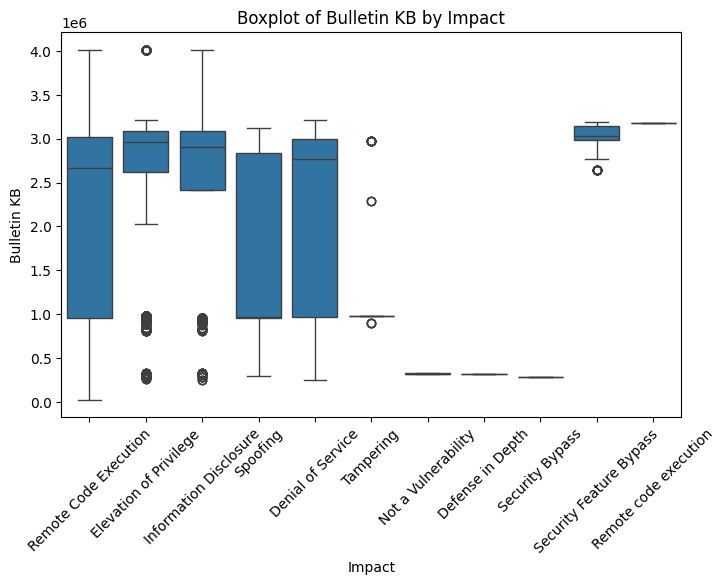

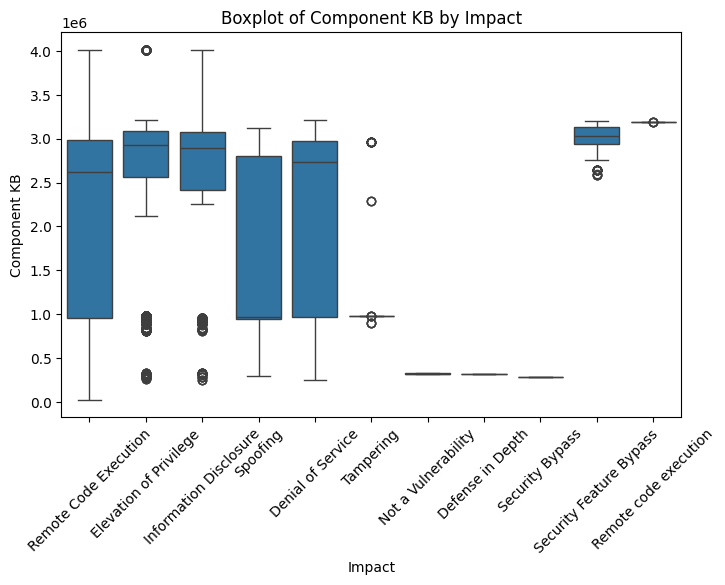

In [ ]:
def box_plots(df: pd.DataFrame, target: str):
    """
    מבצע מבחן ANOVA לכל משתנה מספרי ב-df מול משתנה מטרה קטגורי ומציג גרף boxplot + barplot.

    :param df: DataFrame עם משתנים מספריים וקטגוריים.
    :param target: שם המשתנה הקטגורי (משתנה המטרה).
    """

    # בדיקה שהמשתנה המטרה קיים
    if target not in df.columns:
        raise ValueError(f"המשתנה {target} לא נמצא ב-DataFrame")

    # בדיקה שהמשתנה המטרה הוא קטגורי
    if df[target].dtype not in ['object', 'category']:
        raise ValueError("משתנה המטרה חייב להיות קטגורי")

    numeric_cols = df.select_dtypes(include=['number']).columns  # מזהה משתנים מספריים
    results = {}

    for col in numeric_cols:
        unique_values = df[target].nunique()
        if unique_values < 2:
            print(f"Skipping {col}: המשתנה המטרה מכיל רק קטגוריה אחת")
            continue

        groups = [df[col][df[target] == cat].dropna() for cat in df[target].unique()]
        stat, p_value = stats.f_oneway(*groups)
        results[col] = {'F-Statistic': stat, 'p-value': p_value}

        # יצירת גרף Boxplot
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f'Boxplot of {col} by {target}')
        plt.xlabel(target)
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.show()

print('Box Plot Of Severity :')
box_plots(df=df,target='Severity')

print('='*100)
print('Box Plot Of Impact :')
box_plots(df=df,target='Impact')



**explain** :

The **Y-axis** in the graph represents the **file size of security updates** (Bulletin KB) in **kilobytes (KB)**.
The values on the axis range from 0 to 4,000,000 KB (or 4 GB).

Remote Code Execution

Data range: From very small (close to zero) up to approximately 4,000,000 KB.

Median: Around 2,000,000 KB.

Upper quartile (Q3): Close to 3,000,000 KB.

Lower quartile (Q1): Close to 1,000,000 KB.

Outliers: Several values above 4,000,000 KB.

Implication: Security updates of this type tend to be relatively large,
with significant variability in file sizes.

✅ Encoded target column 'Severity' with mapping: {'Critical': np.int64(0), 'Important': np.int64(1), 'Low': np.int64(2), 'Moderate': np.int64(3), nan: np.int64(4)}


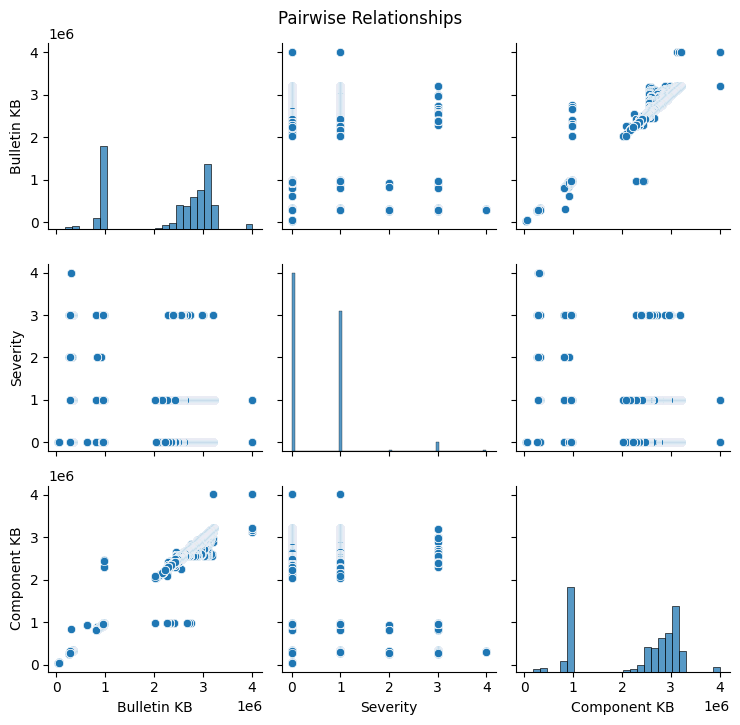

✅ Pairwise relationships plot saved successfully at: /content/plot_active/Pairwise_Relationships.png


In [ ]:

def plot_pairwise_relationships(df, target):
    """
    This function creates a pairplot to visualize pairwise relationships between numeric columns,
    encoding the target column if it's categorical.

    Args:
        df (pd.DataFrame): Input dataframe.
        target (str): Name of the target column to encode.
    """
    df_copy = df.copy()

    # Encode target column if categorical
    if df_copy[target].dtype == 'object' or str(df_copy[target].dtype).startswith('category'):
        le = LabelEncoder()
        df_copy[target] = le.fit_transform(df_copy[target])
        print(f"✅ Encoded target column '{target}' with mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # Select numeric columns only
    numeric_df = df_copy.select_dtypes(include=['number'])

    # Create pairplot
    sns.pairplot(numeric_df)
    plt.suptitle('Pairwise Relationships', y=0.96)
    plt.tight_layout()

    # Save the plot in the existing directory
    save_path = os.path.join('/content/plot_active', 'Pairwise_Relationships.png')
    plt.savefig(save_path)
    plt.show()
    plt.close()

    print(f"✅ Pairwise relationships plot saved successfully at: {save_path}")

# Example call
plot_pairwise_relationships(df, 'Severity')


**explain** :

This Pair Plot (or Scatterplot Matrix) visualizes the pairwise relationships between three variables:

Bulletin KB (security update size in KB)
Severity (severity level)
Component KB (component size in KB)

The plot includes:

Histograms on the diagonal (showing the distribution of each variable).
Scatter plots below and above the diagonal (showing relationships between pairs of variables).

Target - Severity


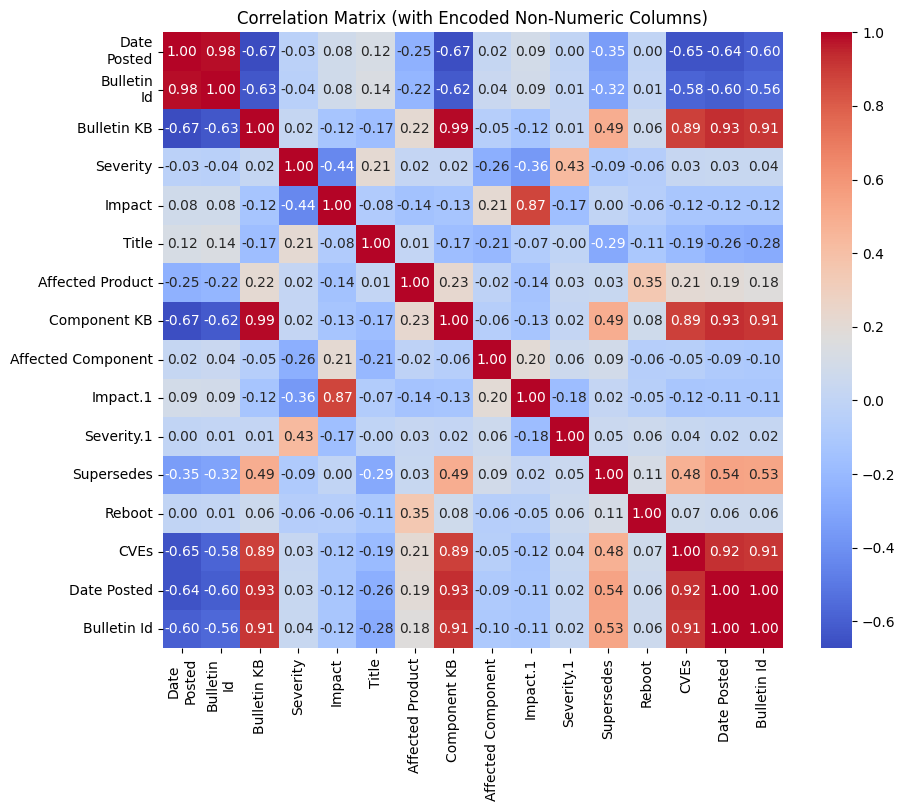

✅ Correlation matrix plot saved successfully.
Date\nPosted         -0.029784
Bulletin\nId         -0.044997
Bulletin KB           0.020318
Severity              1.000000
Impact               -0.437596
Title                 0.210269
Affected Product      0.018747
Component KB          0.016920
Affected Component   -0.261321
Impact.1             -0.362760
Severity.1            0.430300
Supersedes           -0.089698
Reboot               -0.062620
CVEs                  0.028733
Date Posted           0.034825
Bulletin Id           0.038791
Name: Severity, dtype: float64
Target - Impact


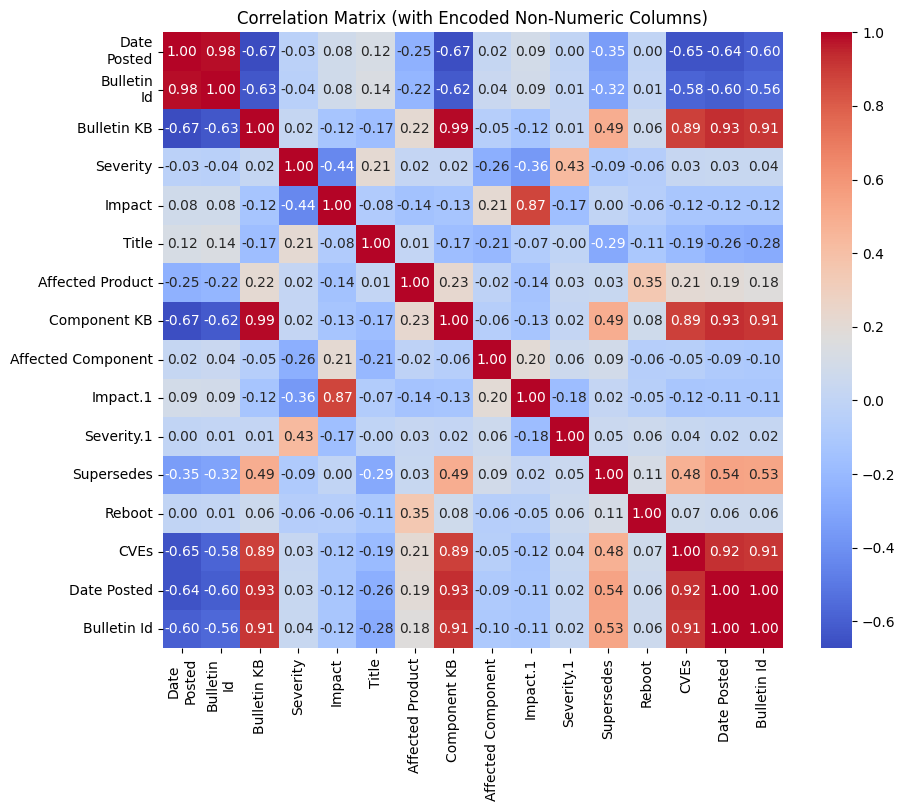

✅ Correlation matrix plot saved successfully.
Date\nPosted          0.082392
Bulletin\nId          0.080616
Bulletin KB          -0.124385
Severity             -0.437596
Impact                1.000000
Title                -0.080931
Affected Product     -0.144484
Component KB         -0.128961
Affected Component    0.210862
Impact.1              0.874265
Severity.1           -0.168419
Supersedes            0.001347
Reboot               -0.057956
CVEs                 -0.118648
Date Posted          -0.119748
Bulletin Id          -0.120858
Name: Impact, dtype: float64


In [ ]:
def plot_correlation_matrix_with_all_columns(df,target):
    """
    This function generates a heatmap of the correlation matrix for all columns in the dataframe.
    Non-numeric columns are encoded numerically before calculating the correlation matrix.

    Args:
        df (pd.DataFrame): Input dataframe.
    """
    # Copy the dataframe to avoid modifying the original
    df_encoded = df.copy()

    # Convert non-numeric columns to numeric using category encoding
    for col in df_encoded.select_dtypes(exclude='number').columns:
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

    # Calculate and plot the correlation matrix
    plt.figure(figsize=(10, 8))
    correlation_matrix = df_encoded.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix (with Encoded Non-Numeric Columns)')
    plt.savefig('/content/plot_active/plot_correletion')
    plt.show()
    plt.close()
    print("✅ Correlation matrix plot saved successfully.")
    return correlation_matrix[target]

print(f'Target - Severity')
print(plot_correlation_matrix_with_all_columns(df,'Severity'))

print(f'Target - Impact')
print(plot_correlation_matrix_with_all_columns(df,'Impact'))

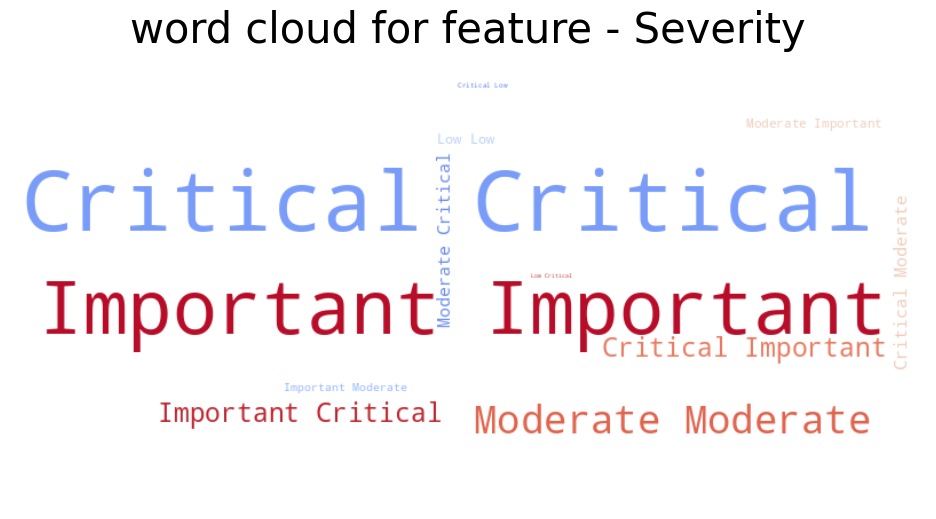

🎯 cloud for Severity completed !
We need at least 1 word to plot a word cloud, got 0.


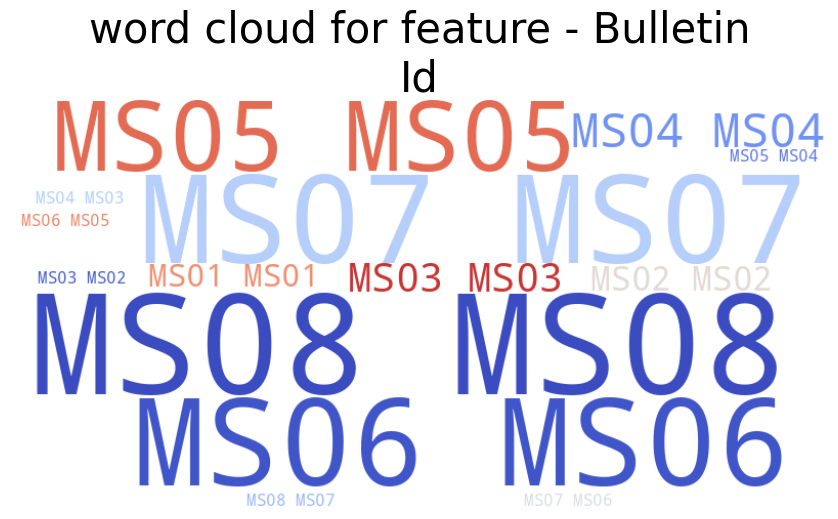

🎯 cloud for Bulletin
Id completed !
We need at least 1 word to plot a word cloud, got 0.


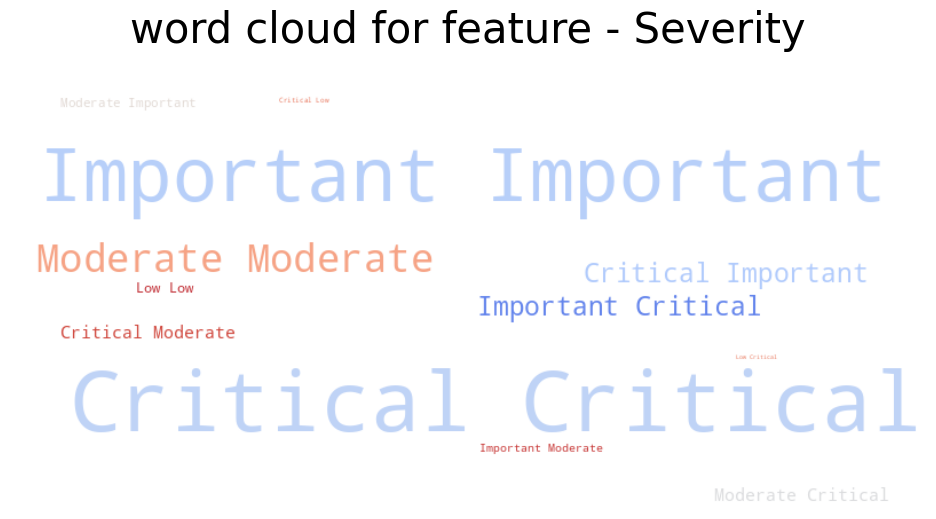

🎯 cloud for Severity completed !


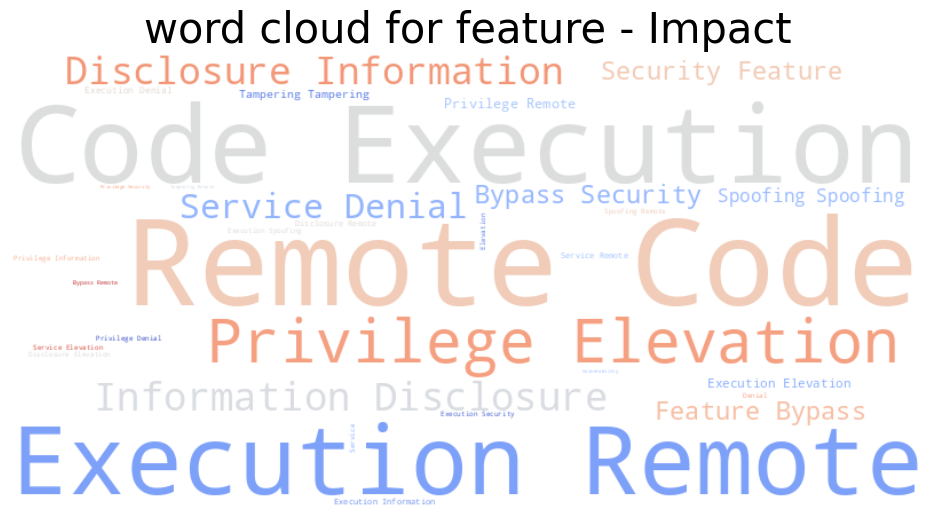

🎯 cloud for Impact completed !


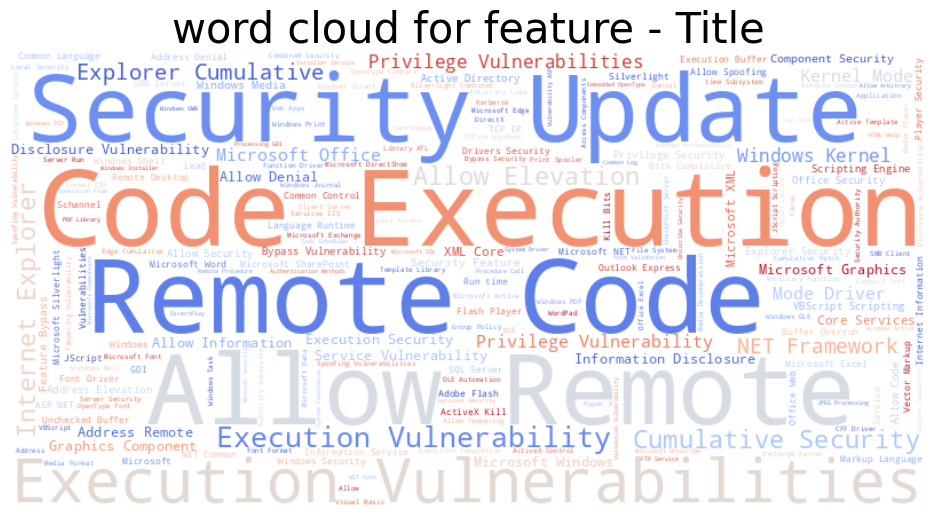

🎯 cloud for Title completed !


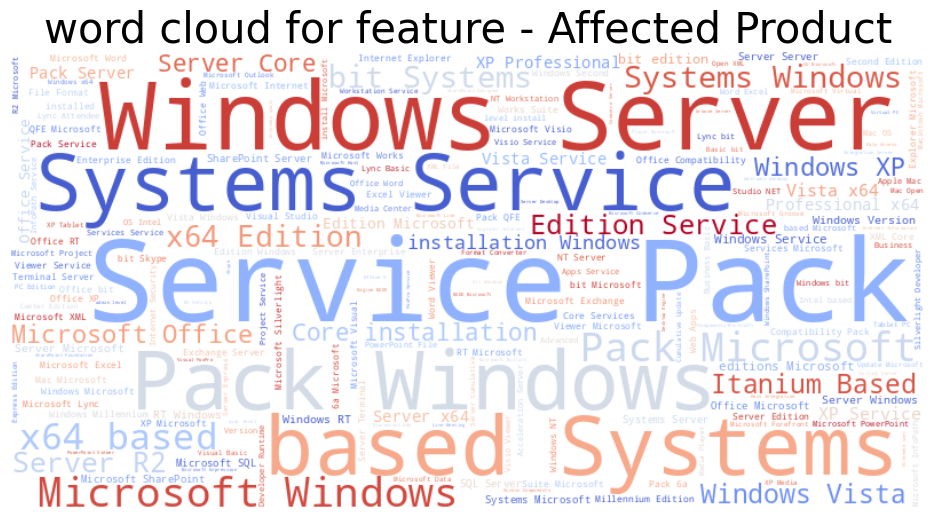

🎯 cloud for Affected Product completed !
We need at least 1 word to plot a word cloud, got 0.


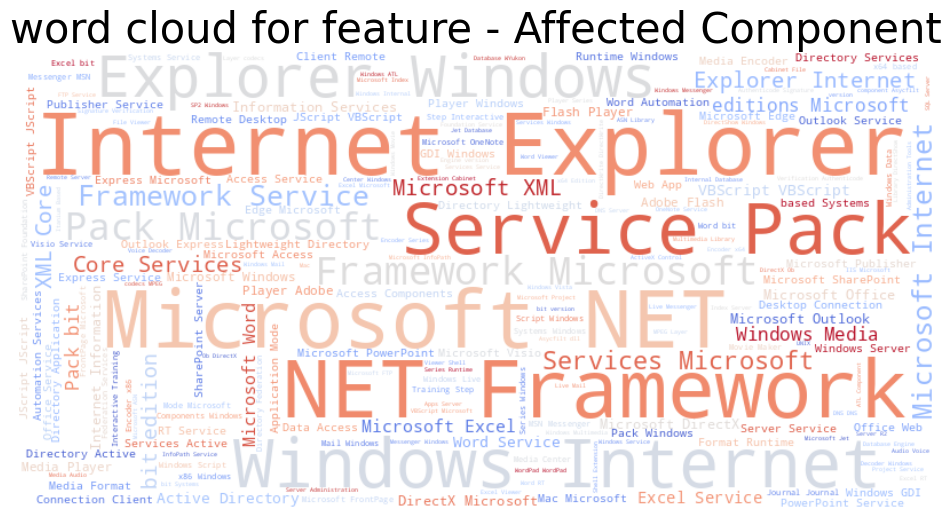

🎯 cloud for Affected Component completed !


In [ ]:
def create_wordcloud_for_target(df, target_column):
    # ודא שהעמודה קיימת ב-DataFrame
    if target_column not in df.columns:
        print(f"עמודה {target_column} לא קיימת ב-DataFrame.")
        return

    # המרת הערכים בעמודה לטקסט
    text = ' '.join(df[target_column].dropna().astype(str))

    # יצירת מפת מילים
    wordcloud = WordCloud(width=800, height=400, background_color='white',colormap='coolwarm').generate(text)

    # הצגת המפה
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"word cloud for feature - {target_column}", fontsize=30)  # 🔵 הוספת כותרת
    plt.tight_layout(pad=0)  # אופציונלי: להקטין רווחים מסביב
    plt.show()
    print(f'🎯 cloud for {target_column} completed !')
    # שמירה לקובץ
    wordcloud.to_file(f"/content/plot_active/{target_column}_wordcloud.png")
nums = 0
create_wordcloud_for_target(df, 'Severity')
for i in df.columns:
  nums+=1
  if nums==10 :
    break
  try:
    create_wordcloud_for_target(df, i)
  except Exception as e:
    print(e)


In [ ]:
c = ['Date\nPosted', 'Bulletin\nId', 'Bulletin KB', 'Severity', 'Impact',
       'Title', 'Affected Product', 'Component KB', 'Affected Component',
       'Impact.1', 'Severity.1', 'Supersedes', 'Reboot', 'CVEs', 'Date Posted',
       'Bulletin Id']

df_fig = df.copy()
df_fig = df_fig.dropna(how='all')

dates = list(df_fig['Date\nPosted'])
severity = df_fig['Severity'].astype(str).tolist()
reboot = df_fig['Reboot'].astype(str).tolist()
impact = list(df_fig['Impact'])
encoder = LabelEncoder()
severity_encode = encoder.fit_transform(df_fig['Severity'])

print(df.dtypes)

Date\nPosted          datetime64[ns]
Bulletin\nId                  object
Bulletin KB                  float64
Severity                      object
Impact                        object
Title                         object
Affected Product              object
Component KB                 float64
Affected Component            object
Impact.1                      object
Severity.1                    object
Supersedes                    object
Reboot                        object
CVEs                          object
Date Posted           datetime64[ns]
Bulletin Id                   object
dtype: object


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

c = ['Date\nPosted', 'Bulletin\nId', 'Bulletin KB', 'Severity', 'Impact',
       'Title', 'Affected Product', 'Component KB', 'Affected Component',
       'Impact.1', 'Severity.1', 'Supersedes', 'Reboot', 'CVEs', 'Date Posted',
       'Bulletin Id']


# יצירת פיגר עם 2 שורות ו-2 עמודות
fig = make_subplots(
    rows=2, cols=2,
    specs=[[ {"type": "scatter","colspan":2},None],
           [{"type": "bar"}, {"type": "pie"}]],
    subplot_titles=['time by severity' ,'scatter of impact','pie of reboot'],
)


# תרשים Scatter
fig.add_trace(go.Scatter(
    x=dates, y=severity,
    mode='lines+markers', name='Severity by Dates',
    marker=dict(color='black'),
    line=dict(color='skyblue'),
), row=1, col=1)

# תרשים Bar
impact_counts = df['Impact'].value_counts().sort_index()

fig.add_trace(go.Bar(
    x=impact_counts.index,                   # שמות הקטגוריות
    y=impact_counts.values,                  # מספר מופעים
    text=[f"{val}" for val in impact_counts.values],  # טקסט מעל כל עמודה
    textposition='outside',
    textfont=dict(
        size=10,
        color='black'
    ),
    marker=dict(
        color='yellow',
        line=dict(color='black', width=1)
    ),
    opacity=0.9,
    name='count of Impact'
), row=2, col=1)
# ספירה של ערכים בעמודת 'reboot'

rc = df['Reboot'].value_counts().sort_index()

# תרשים עוגה (Pie)
fig.add_trace(go.Pie(
    labels=rc.index,             # ערכים ייחודיים ממוינים
    values=rc.values,            # מספר מופעים לכל אחד
    marker=dict(colors=['blue', 'red', 'green']),
    textinfo='label+percent',    # הצגת תווית ואחוזים
    hoverinfo='label+value'      # מה שמוצג ב-hover
), row=2, col=2)


# עדכון עיצוב כללי
fig.update_layout(
    height=850,
    title_text="Security Microsoft Graphs",
    uniformtext_minsize=5,
    uniformtext_mode='hide'
)

fig.show()
fig.write_html("Dinamic_graphs.html")

# *🧩🔧 Impute Missing Values *




In [ ]:
max_d = 12
fontsize = 3

dict_best_model = {}
os.makedirs('decision trees', exist_ok=True)
os.makedirs('output data', exist_ok=True)
##############################################################################################################################################
##############################################################################################################################################
'''
ממלא ערכים חסרים בעמודות קטגוריאליות לפי אסטרטגיה מוגדרת.
משתמש ב-SimpleImputer להשלמת ערכים חסרים כגון None או NaN.
'''

print(f'[parameters : max deeps = {max_d} , fontsize = {fontsize}]')
print('='*444)
#🍻
def fill_missing_categorical_values(df, strategy='most_frequent'):
    # המרת None ל-nan
    df = df.replace({None: np.nan})

    # יצירת SimpleImputer עבור עמודות קטגוריאליות
    imputer = SimpleImputer(strategy=strategy, fill_value='missing')

    # התאמת האימפוטר ל-DataFrame
    filled_array = imputer.fit_transform(df)
    df = pd.DataFrame(filled_array, columns=df.columns)

    columns = df.columns
    # הצגת ערכי המילוי שנבחרו
    for col, fill_value in zip(columns, imputer.statistics_):
        print(f"column {col} filled by :  {fill_value}")
    # החזרת DataFrame ממולא
    return df


#decision_tree_model(filled_df, target)

##############################################################################################################################################
##############################################################################################################################################
#🍻
'''
מחלק את הנתונים לשתי קבוצות: אחת עם ערכים חסרים בעמודת היעד ואחת בלי.
מאפשר טיפול נפרד בנתונים עם ובלי ערך יעד.
'''
def split_by_target_null(df):
    df_null_target = df[df[target].isnull()]
    df_not_null_target = df[df[target].notnull()]
    return df_null_target, df_not_null_target


##############################################################################################################################################
##############################################################################################################################################
'''
מאמן מודל עץ החלטה לחיזוי ערכים חסרים בעמודת היעד.
מציג מטריצת בלבול, דיוק המודל, ותרשים עץ החלטה.
'''
#🍻
def tree_model(df,df_null, target,name):
    df_not_target = df.drop(columns=[target])
    df_null_not_target = df_null.drop(columns=[target]) # this df has null in target

    df_combined = pd.concat([df_not_target, df_null_not_target])
    df_combined_dummies = pd.get_dummies(df_combined)

    df1_dummies = df_combined_dummies.iloc[:len(df)]
    df2_dummies_ob = df_combined_dummies.iloc[len(df):]

    X = df1_dummies
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    print(f'Confusion Matrix:\n{cm}')

    accuracy = accuracy_score(y_test, y_pred)
    #predict for df_null
    df_2_predict = model.predict(df2_dummies_ob)

    df_null.loc[:, target] = df_2_predict

    print(f'predict :\n {df_2_predict}')

    # הגבלת שמות הפיצ'רים ל-20 תווים
    max_length = 20
    truncated_feature_names = [name[:max_length] for name in X.columns]

    plt.figure(figsize=(12, 8))
    plot_tree(
        model,  # מודל העץ עצמו
        filled=True,  # צבע את המלבן בהתאם למחלקה (True=צבע מלא, False=לא)
        feature_names=truncated_feature_names,  # שמות הפיצ'רים (עמודות) ששימשו לאימון המודל
        class_names=model.classes_.astype(str),  # שמות המחלקות בתוויות (במקרה הזה המרתן למחרוזות)
        rounded=True,  # עיגול הפינות של המלבן (True=עיגול פינות, False=פינות חדות)
        max_depth=max_d,  # העמק (max_depth) של העץ, כלומר עד איזו רמה לעומק לצייר את העץ
        fontsize=fontsize,  # גודל הגופן של הטקסט בעץ
        precision=2,  # רמת דיוק של ציון המידע בתוך המלבן (כמו אחוזים)
        proportion=True,  # האם להציג את הערכים היחסיים של כל מחלקה (True=מינונים יחסיים)
        label='all',  # לציין אם להציג את כל התוויות בכל צומת (אפשר גם 'root', 'none', 'all')
    )

    plt.title("Decision Tree Model")
    #plt.show()
    plt.savefig(os.path.join('decision trees',f'tree of {name} for predict missing target.png'))

    dict_best_model['decision tree model missing data'] = accuracy
    return model, accuracy , df_null

##############################################################################################################################################
##############################################################################################################################################
#🍻
'''
מאמן מודל עץ החלטה על הנתונים המלאים ומחשב דיוק.
חוזה ערכים לנתונים חדשים ומציג תרשים עץ החלטה.
הנתונים המלאים ללא ערכים חסרים
'''
def train_decision_tree_filled_data(df, target ,new_data):
    # המרת משתנים קטגוריאליים לדמי

    # חיתוך הנתונים בין תכונות (X) ליעד (y)
    X = df.drop(columns=[target])  # כל העמודות חוץ מהיעד
    y = df[target]  # העמודה שמייצגת את היעד

    X = pd.get_dummies(X, drop_first=True) #dummies fichers
    print(f'--------- shape of dummy : {X.shape}')
    #pd.concat([X,y]).to_csv(os.path.join('output data' , 'dummies values frame.csv'))
    #print('---------- saved dummies values frame successfully')
    # חיתוך הנתונים לסט אימון וסט מבחן
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # יצירת המודל
    model = DecisionTreeClassifier(random_state=42)

    # אימון המודל
    model.fit(X_train, y_train)

    # חיזוי על סט המבחן
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f'Confusion Matrix for full dataFrame : \n{cm}')


    # חישוב הדיוק
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')


    # הגבלת שמות הפיצ'רים ל-20 תווים
    max_length = 20
    truncated_feature_names = [name[:max_length] for name in X.columns]

    # הצגת עץ החלטה
    plt.figure(figsize=(12, 8))
    plot_tree(
        model,  # מודל העץ עצמו
        filled=True,  # צבע את המלבן בהתאם למחלקה (True=צבע מלא, False=לא)
        feature_names=truncated_feature_names,  # שמות הפיצ'רים (עמודות) ששימשו לאימון המודל
        class_names=model.classes_.astype(str),  # שמות המחלקות בתוויות (במקרה הזה המרתן למחרוזות)
        rounded=True,  # עיגול הפינות של המלבן (True=עיגול פינות, False=פינות חדות)
        max_depth=max_d,  # העמק (max_depth) של העץ, כלומר עד איזו רמה לעומק לצייר את העץ
        fontsize=fontsize,  # גודל הגופן של הטקסט בעץ
        precision=2,  # רמת דיוק של ציון המידע בתוך המלבן (כמו אחוזים)
        proportion=True,  # האם להציג את הערכים היחסיים של כל מחלקה (True=מינונים יחסיים)
        label='all',  # לציין אם להציג את כל התוויות בכל צומת (אפשר גם 'root', 'none', 'all')
    )
    plt.title("Decision Tree Model")
    plt.savefig(os.path.join('decision trees',f'decision_tree_{target} - full dataFrame.png'))  # לשמור את העץ כקובץ תמונה

    try:
      # המרת התצפית החדשה לדמיות
      new_data_dummies = pd.get_dummies(new_data)
      # מוודאים שהתצפית החדשה כוללת את כל העמודות של X מהמודל, וממלאים ערכים חסרים ב-0
      new_data_dummies = new_data_dummies.reindex(columns=X.columns, fill_value=0)
      # חיזוי עם המודל
      new_prediction = model.predict(new_data_dummies)
      # הדפסת התוצאה
      #print(f'Predicted value for the new data: {new_prediction}')
      dict_best_model['decision tree model filled all data'] = accuracy
    except Exception as e:
      print(e)


    print(f'evulate model : dicision tree model - acc {accuracy} , f1 {f1} , precision {precision}')
    return model, accuracy , new_prediction



##############################################################################################################################################
##############################################################################################################################################
#🍻
'''
ממיר עמודת תאריך לפורמט מספרי עם יום, חודש ושנה.
מזהה מפריד תאריך אוטומטית ומטפל בשגיאות המרה.
'''
def convert_to_datetime(df, column_name, separator='-'):
    df[column_name] = df[column_name].astype(str)
    if df[column_name].str.contains(r'\.', regex=True).any():
        separator = '.'
    elif df[column_name].str.contains(r'\\', regex=True).any():
        separator = '\\'
    else:
        separator = '-'
    try:
        # מפרידים את התאריך לחלקים (יום, חודש, שנה)
        df[['Year', 'Month', 'Day']] = df[column_name].str.split(separator, expand=True)

        # הופכים את העמודות לנתונים מספריים (אם הם לא כבר ככה)
        df['Day'] = pd.to_numeric(df['Day'], errors='coerce')
        df['Month'] = pd.to_numeric(df['Month'], errors='coerce')
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

        # מוחקים את עמודת התאריך המקורית
        df = df.drop(columns=[column_name])

    except Exception as e:
        print(f"Error occurred while converting date: {e}")
    return df

[parameters : max deeps = 12 , fontsize = 3]


In [ ]:
df.dtypes

,0
Date\nPosted,datetime64[ns]
Bulletin\nId,object
Bulletin KB,float64
Severity,object
Impact,object
Title,object
Affected Product,object
Component KB,float64
Affected Component,object
Impact.1,object


null in last row : 
nan
null in target row : 
Severity    17
dtype: int64
null in all data before impute : 
Date\nPosted          19066
Bulletin\nId          19066
Bulletin KB              45
Severity                 17
Impact                    0
Title                     0
Affected Product          2
Component KB             21
Affected Component    12154
Impact.1                  0
Severity.1              426
Supersedes            10486
Reboot                  390
CVEs                    185
Date Posted            4450
Bulletin Id            4450
dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
column Bulletin Id filled by :  MS13-081
column Bulletin KB filled by :  2870008.0
column Impact filled by :  Remote Code Execution
column Title filled by :  Cumulative Security Update for Internet Explorer
c

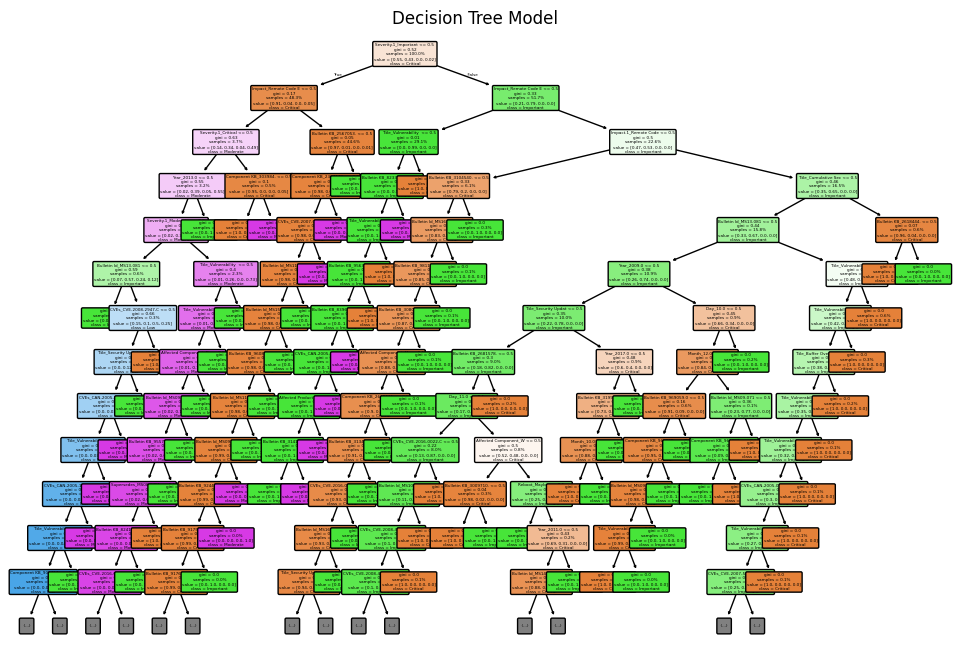

In [ ]:
data_csv = df.copy()
last_row = data_csv.iloc[-1:]  # שכפול השורה האחרונה של ה-DataFrame
data_csv = pd.concat([data_csv, last_row], ignore_index=True)  # הוספת השורה המשוכפלת כנתון חדש

data_csv.at[data_csv.index[-1], 'Severity'] = np.nan  # שינוי הערך בעמודת 'Severity' בשורה האחרונה ל-NaN

print(f'null in last row : \n{data_csv.iloc[-1]["Severity"]}')  # הדפסת הערך של 'Severity' בשורה האחרונה


features =  [
    "Date Posted", "Bulletin Id", "Bulletin KB",  "Impact", "Title",
    "Affected Product", "Component KB", "Affected Component", "Impact.1",
    "Severity.1", "Supersedes", "Reboot", "CVEs"
]

target = 'Severity' # מטרה
target_row = data_csv[target]# קבלת המטרה

data = data_csv[features] # קבלת הפיצרים מהנתונים

df_features = pd.DataFrame(data) # דאטהםריים של פיצרים
df_features = convert_to_datetime(df_features, 'Date Posted') # הפרדת התאריך מפורמט תאריך כי הוא לא עובד

df_target = pd.DataFrame(target_row , columns = [target]) # דאטהפריים של מטרה
null_target = df_target.isnull().sum() # בדיקה כמה נאלים יש במטרה
print(f'null in target row : \n{null_target}') #הדפסת נאלים של מטרה
print(f'null in all data before impute : \n{data_csv.isnull().sum()}') #הדפסת נאלים של מטרה
print('-'*222)

filled_df = fill_missing_categorical_values(df_features)# מילוי ערכים חסרים בעמודות קטגוריאליות

filled_df.to_excel(os.path.join('output data' , '1 - Data filled in featurs.xlsx'), index=False) # שמירה' ), index=False) # שמירה)

full_df_concat = pd.concat([filled_df, df_target] , axis=1) # חיבור הנתונים המלאים של מטרה ופיצרים
full_df_concat.to_excel(os.path.join('output data' , r'2 - All data filled with target.xlsx'), index=False) # שמירה

print (f'null value in full df :\n{full_df_concat.isnull().sum()}') # בדיקה אם יש נאלים בפריים החדש המלא
print('='*222)

#🧠 Using Fill Algorithm for missing data
if (null_target > 0).all():
    # פיצול הנתונים לשורות עם ובלי ערכים חסרים בעמודת היעד
    null_target_row, not_null_target_row = split_by_target_null(full_df_concat)
    null_target_row.to_csv(os.path.join('output data','divide dataframe null in severity.csv'))
    # אימון מודל עץ החלטה על הנתונים המלאים והשערת הערכים החסרים
    model, accuracy, null_target_row = tree_model(not_null_target_row, null_target_row, target, 'Severity')
    print('the accuracy of first model with part of df not null (tree model) : ')  # הדפסת הודעה על ביצועי המודל הראשון
    print(f'accuracy : {accuracy}')  # הדפסת דיוק המודל
    full_df_all = pd.concat([not_null_target_row, null_target_row], ignore_index=True)  # שילוב חזרה של הנתונים עם ובלי הערכים החסרים לאחר מילוי
else:
    print("No null values in target row, training model on full data.")  # הודעה אם אין ערכים חסרים בעמודת היעד
    full_df_all = full_df_concat  # שימוש בכל הנתונים ללא צורך בפיצול

print('='*222)  # הדפסת קו מפריד באורך 222 תווים
full_df_all.to_excel(os.path.join('output data' , r'3 - Original alldata filled with target.xlsx'), index=False) # שמירה

In [ ]:
df_proccess = pd.read_excel('/content/output data/3 - Original alldata filled with target.xlsx')

In [ ]:
print(f'null in proccess df : {df_proccess.isnull().sum()}')
print('✅ Misssion Complete')

null in proccess df : Bulletin Id           0
Bulletin KB           0
Impact                0
Title                 0
Affected Product      0
Component KB          0
Affected Component    0
Impact.1              0
Severity.1            0
Supersedes            0
Reboot                0
CVEs                  0
Year                  0
Month                 0
Day                   0
Severity              0
dtype: int64
✅ Misssion Complete


#🤖 **Model**

**main model - CatBoost**

The CatBoost (Category Boosting) model is a gradient-boosting framework specifically designed to handle categorical features natively, without requiring manual preprocessing like one-hot or ordinal encoding.

Developed by Yandex, CatBoost stands out for its ability to work seamlessly with mixed data types, including numerical, categorical, and even text or time-series data.

It automatically converts categorical values into numerical representations using advanced techniques like target-based statistics and ordered boosting, which help prevent overfitting and improve prediction accuracy.

CatBoost is highly effective for both classification and regression tasks, offering robust performance even with missing values or noisy data.

 Its built-in support for categorical features eliminates the need for manual encoding, simplifying the preprocessing pipeline.

 Additionally, CatBoost provides tools for hyperparameter tuning, feature importance analysis, and visualization, making it a versatile and user-friendly choice for machine learning applications. Its ability to handle categorical data efficiently makes it particularly valuable in real-world scenarios where datasets often contain a mix of feature types.



lr - 0.13834061227219888
0:	learn: 1.0842458	total: 109ms	remaining: 16.8s
100:	learn: 0.0212082	total: 13s	remaining: 7.05s
155:	learn: 0.0183143	total: 20s	remaining: 0us
Number of trees in model: 156
🐱 metrics : {'Accuracy': 0.9995203376822717, 'F1 Score': 0.9995203428687551, 'Precision': 0.9995203672062929, 'Recall': 0.9995203376822717}
best lr =0.13834061227219888


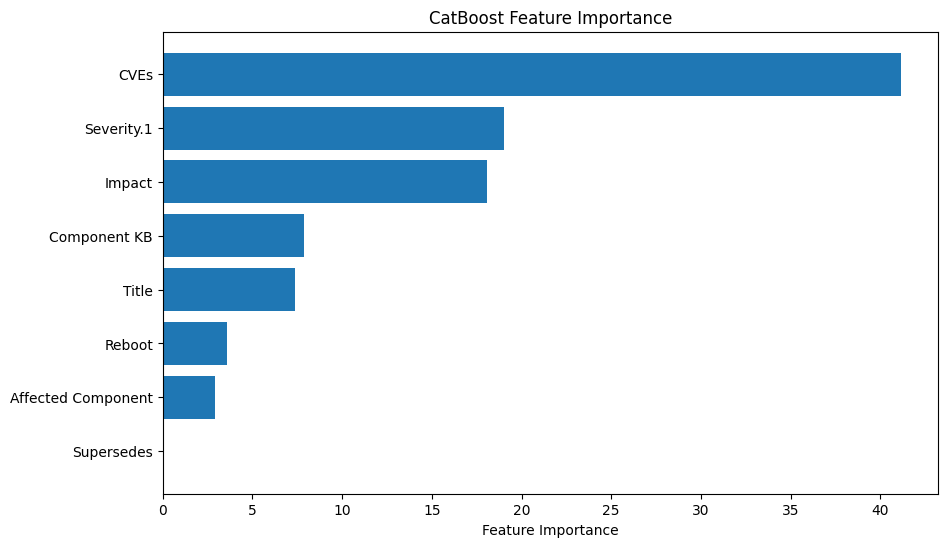

'\nhow to load model -\n\nfrom catboost import CatBoostClassifier\n\nloaded_model = CatBoostClassifier()\nloaded_model.load_model("my_catboost_model.cbm")\n\n'

In [ ]:
from catboost import Pool
current_F = ['Impact','Title','Severity.1','Supersedes','Reboot','CVEs','Affected Component','Component KB','Severity']
currect_frame = df_proccess[current_F]
df_0 = currect_frame.copy()

test = 0.443251
i=156
D=6
features = ['Impact',
            'Title',
            'Severity.1',
             'Supersedes',
             'Reboot',
             'CVEs',
             'Affected Component',
             'Component KB']
def train_catboost_(df: pd.DataFrame,iterations : int , features: list, target: str, cat_features: list = None,
                   task: str = "classification" , test = 0.2 , Depth = 6 , LR=0.1):

    """
    פונקציה לאימון מודל CatBoost והערכתו במדדים שונים בהתאם לסוג המשימה.
    :param df: DataFrame עם הנתונים
    :param features: רשימת שמות העמודות של הפיצ'רים
    :param target: שם עמודת המטרה
    :param cat_features: רשימת שמות של משתנים קטגוריים (אופציונלי)
    :param task: סוג המשימה - "classification" או "regression"
    :param tree_idx: מספר העץ לציור
    :return: המודל המאומן, המטריקות, וסט האימון
    """
    X = df.drop(columns=target)
    y = df[target]

    # זיהוי משתנים קטגוריים אם לא סופקו
    if cat_features is None:
        cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    # המרת משתנים קטגוריים לקטגוריה
    for col in cat_features:
        X[col] = X[col].astype('category')


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= test, random_state=42)

    # The `Pool` class in CatBoost is a special way to give data to the model.
    # It helps CatBoost know which columns are categorical (not numbers).
    # It also makes training faster and uses less memory.
    train_pool = Pool(X_train, label=y_train, cat_features=cat_features)
    test_pool = Pool(X_test, label=y_test, cat_features=cat_features)

    if task == "classification":
        model = CatBoostClassifier(iterations=iterations, learning_rate=LR, depth=Depth, verbose=100,thread_count = -1)
    elif task == "regression":
        model = CatBoostRegressor(iterations=iterations, learning_rate=LR, depth=Depth, verbose=0)
    else:
        raise ValueError("Task must be either 'classification' or 'regression'")

    # אימון המודל
    model.fit(train_pool)

    # חיזוי על סט הבדיקה
    y_pred = model.predict(X_test)

    # מדדים לפי סוג המשימה
    if task == "classification":
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')



        metrics = {"Accuracy": accuracy, "F1 Score": f1, "Precision": precision, "Recall": recall}
    else:
        rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
        mae = mean_absolute_error(y_test, y_pred)

        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")

        metrics = {"RMSE": rmse, "MAE": mae}

    # הצגת כמות העצים במודל
    print(f"Number of trees in model: {model.tree_count_}")

    return model, metrics, X_train


def plot_feature_importance(model, features):
    feature_importance = model.get_feature_importance()


    if len(feature_importance) != len(features):
        print(f"Warning: Model has {len(feature_importance)} features but features list has {len(features)}")
        features = model.feature_names_  # קבלת שמות הפיצ'רים מהמודל ישירות

    sorted_idx = np.argsort(feature_importance) # מיון הפיצ׳רים

    #הוצאת גרף bar
    plt.figure(figsize=(10, 6))
    plt.barh([features[i] for i in sorted_idx], feature_importance[sorted_idx])
    plt.xlabel("Feature Importance")
    plt.title("CatBoost Feature Importance")
    plt.show()



lr=0.13834061227219888
print(f'lr - {lr}')
catMod, metrics , x_train = train_catboost_(df_0, iterations=i, features=features, target='Severity', task="classification",
                                        test=test, Depth=D, LR=lr)
print(f'🐱 metrics : {metrics}')
print(f'best lr ={lr}')

plot_feature_importance(catMod, features)
catMod.save_model("my_catboost_model.cbm")
'''
how to load model -

from catboost import CatBoostClassifier

loaded_model = CatBoostClassifier()
loaded_model.load_model("my_catboost_model.cbm")

'''



In [ ]:
import numpy as np
import sympy
import sympy as sp
import math
import matplotlib.pyplot as plt



x = sympy.Symbol('x')
# פונקציית רגרסיה עם NumPy
def reg_accuracy_by_numpy(acc_dict,deg=2):
    global x
    x_vals = np.array(list(acc_dict.keys()))
    y_vals = np.array(list(acc_dict.values()))
    coeffs = np.polyfit(x_vals, y_vals, deg=deg)
    fx = sum(coef * x**i for i, coef in enumerate(reversed(coeffs)))

    return fx
def draw_fx(fx, acc_dict,  num_points=100):
    x_range = (0, max(acc_dict.keys()))
    x = sp.Symbol('x')
    fx_numeric = sp.lambdify(x, fx, modules=['numpy'])

    # טווח ערכים לציר X
    x_vals = np.linspace(x_range[0], x_range[1], num_points)
    y_vals = fx_numeric(x_vals)

    # המרת dict לרשימות
    dict_x = list(acc_dict.keys())
    dict_y = list(acc_dict.values())

    # ציור
    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, y_vals, label=f"y = {sp.simplify(fx)}", color='blue')  # קו רגרסיה
    plt.scatter(dict_x, dict_y, color='red', label='Original Data')  # נקודות הנתונים המקוריים

    plt.axhline(0, color='black', linewidth=0.5)  # ציר X
    plt.axvline(0, color='black', linewidth=0.5)  # ציר Y
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Linear Regression + Original Data")
    plt.grid(True)
    plt.legend()
    plt.show()


**model - Extra Tree**

The Extra Trees  model is an ensemble machine learning algorithm that improves upon the Random Forest method by introducing additional randomness during tree construction. Unlike Random Forest, which carefully selects the best split points for features, Extra Trees randomly chooses both the features and the split thresholds, creating a diverse set of decision trees that collectively reduce overfitting and enhance generalization.

This approach makes the model faster to train and often more robust, especially for high-dimensional datasets, as the increased randomness helps decorrelate individual trees. However, like other tree-based models, Extra Trees does not inherently support categorical variables, so they must first be encoded—typically using techniques like ordinal encoding for ordered categories (e.g., "Low," "Medium," "High") or one-hot encoding for nominal categories (e.g., colors or country names)—before training.


Extra Trees is particularly useful for tasks requiring quick training and strong predictive performance, such as classification or regression problems with many features. By averaging predictions across multiple trees, it balances bias and variance effectively, though the randomness in split selection can make individual trees less interpretable. The model also provides feature importance scores, helping identify the most influential variables in the dataset. Overall, Extra Trees is a powerful choice when you prioritize speed, accuracy, and resistance to overfitting, but it requires proper preprocessing of categorical data to ensure meaningful results.



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
building tree 4 of 300
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
building tree 5 of 300
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    0.2s
building tree 6 of 300
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.2s
building tree 7 of 300[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.3s
building tree 8 of 300
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.3s

building tree 9 of 300
building tree 10 of 300
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.4s
building tree 11 of 300
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.4s
building tree 12 of 300
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.5s
building tree 13 of 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
building tree 4 of 300
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
building tree 5 of 300
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    0.1s
building tree 6 of 300
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.1s
building tree 7 of 300
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.2s
building tree 8 of 300
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.2s
building tree 9 of 300[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.2s

building tree 10 of 300
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.2s
building tree 11 of 300
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.3s
building tree 12 of 300
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.3s
building tree 13 of 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
building tree 4 of 300
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
building tree 5 of 300
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    0.1s
building tree 6 of 300
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.2s
building tree 7 of 300[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.2s

building tree 8 of 300
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.2s
building tree 9 of 300
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.3s
building tree 10 of 300
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.3s
building tree 11 of 300
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.4s
building tree 12 of 300
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.4s
building tree 13 of 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/tmp/ipython-input-3863669714.py:15: RankWarning:

Polyfit may be poorly conditioned



Accuracy: 0.8667195557318524 | test size: 0.10718125990369697 | max depth: 9


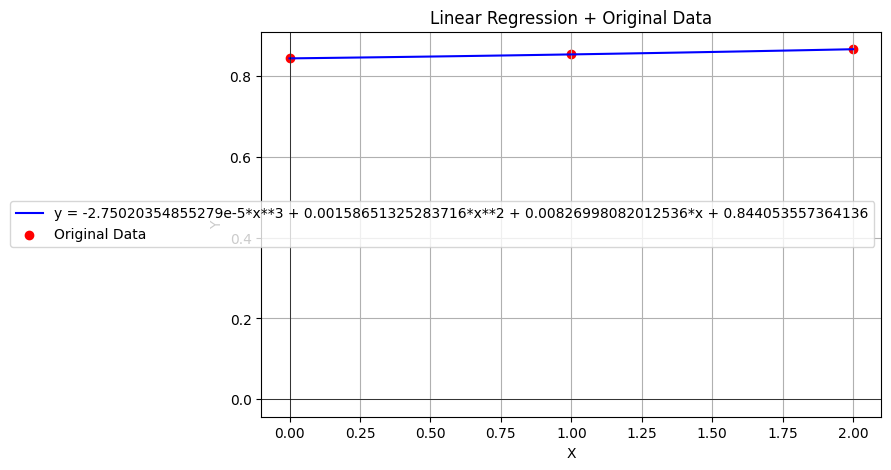

In [ ]:
from sklearn.metrics import classification_report
from sklearn.ensemble import ExtraTreesClassifier

os.makedirs('Reports/Extra_tree', exist_ok=True)
def run_extra_trees_model(df, target_column , T=0.2, N=400, D=10):
    df_encoded = df.copy()

    # הסרת כל העמודות מסוג תאריך
    datetime_cols = df_encoded.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns
    df_encoded.drop(columns=datetime_cols, inplace=True)

    # One-Hot Encoding לכל התכונות הקטגוריאליות למעט עמודת המטרה
    df_encoded = pd.get_dummies(df_encoded, columns=[col for col in df_encoded.columns if col != target_column and df_encoded[col].dtype == 'object'])

    # קידוד עמודת המטרה (אם היא קטגוריאלית)
    le = None
    if df[target_column].dtype == 'object':
        le = LabelEncoder()
        df_encoded[target_column] = le.fit_transform(df[target_column])
        class_names = le.classes_
    else:
        class_names = sorted(df[target_column].unique().astype(str))

    X = df_encoded.drop(columns=[target_column])
    y = df_encoded[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=T, random_state=42)

    model = ExtraTreesClassifier(
        n_estimators=N,
        max_depth=D,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=False,
        n_jobs=-1,
        random_state=42,
        verbose=100
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("✅ Extra Trees Results:")
    print("Accuracy:", acc)

    report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df['accuracy'] = acc

    report_df.to_csv("Reports/Extra_tree/extra_trees_report.csv", index=True)
    print("📄 Classification Report saved to: extra_trees_report.csv")
    print(report_df)

    return model, acc

accu = {}
accMax = 0
testMax = 0
best_D = 0
mon=0
for D in range(5, 10, 2):
  t = random.uniform(0.1, 0.2)
  model, acc = run_extra_trees_model(df=df_0, target_column='Severity', T=t, N=300, D=D)
  accu[mon]=acc
  if acc > accMax:
      accMax = acc
      testMax = t
      best_D = D
  mon+=1

fx = reg_accuracy_by_numpy(acc_dict=accu, deg=3)
print(f'Accuracy: {accMax} | test size: {testMax} | max depth: {best_D}')

draw_fx(fx,acc_dict=accu)


**Model - LightGBM**

The LightGBM (Light Gradient Boosting Machine) model is a highly efficient and scalable gradient boosting framework developed by Microsoft, optimized for speed and performance. Unlike traditional gradient boosting methods, LightGBM uses a leaf-wise growth strategy (instead of level-wise) to build decision trees, which significantly accelerates training while maintaining high accuracy. This approach focuses on splitting leaves that yield the largest reduction in loss, making it particularly effective for large datasets and high-dimensional feature spaces.

LightGBM excels at handling categorical features, though it requires them to be preprocessed into numerical values (e.g., using one-hot or ordinal encoding). It also supports advanced features like parallel learning, GPU acceleration, and handling missing values natively, making it a popular choice for both classification and regression tasks. Its efficiency and scalability make it ideal for applications requiring fast training and deployment, such as real-time recommendation systems or large-scale data competitions. Additionally, LightGBM provides built-in tools for feature importance analysis, hyperparameter tuning, and model interpretation, enhancing its usability in practical machine learning workflows.

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3139
[LightGBM] [Info] Number of data points in the train set: 16461, number of used features: 8
[LightGBM] [Info] Start training from score -0.601882
[LightGBM] [Info] Start training from score -0.852801
[LightGBM] [Info] Start training from score -6.412912
[LightGBM] [Info] Start training from score -3.714788
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

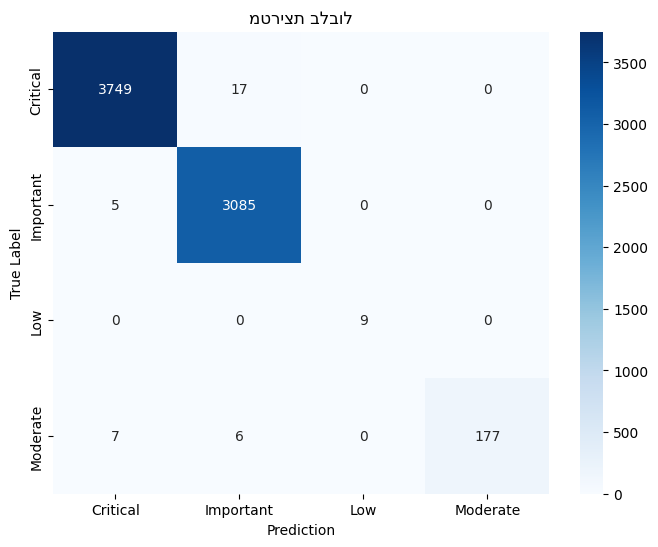

depth = 15 , accuracy = 0.9950389794472005


In [ ]:
import lightgbm as lgb

def run_lightgbm_model(df , T=3):
    # המרת עמודת המטרה לערכים מספריים
    target = df['Severity']

    # הסרת עמודת המטרה
    df_features = df.drop('Severity', axis=1)

    # זיהוי משתנים קטגוריאליים
    categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()

    # המרת כל המשתנים הקטגוריאליים לקטגוריות (LightGBM תומך בזה באופן טבעי)
    for column in categorical_cols:
        df_features[column] = df_features[column].astype('category')

    # פיצול הנתונים לסט אימון וסט בדיקה
    X_train, X_test, y_train, y_test = train_test_split(df_features, target, test_size=0.3, random_state=42)

    # יצירת המודל
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.01,
        max_depth=T,
        num_leaves=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1
    )

    # אימון המודל
    model.fit( X_train, y_train,
    categorical_feature=categorical_cols,

    )

    # חיזוי על סט הבדיקה
    y_pred = model.predict(X_test)

    # תוצאות
    print("דיוק (Accuracy):", accuracy_score(y_test, y_pred))
    print("\nדוח סיווג:\n", classification_report(y_test, y_pred))
    print("\nמטריצת בלבול:\n", confusion_matrix(y_test, y_pred))

    # חישוב הדיוק ודוח הסיווג
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    # הצגת מטריצת בלבול בתמונה
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Critical', 'Important', 'Low', 'Moderate'],
                yticklabels=['Critical', 'Important', 'Low', 'Moderate'])
    plt.title("מטריצת בלבול")
    plt.xlabel("Prediction")
    plt.ylabel("True Label")
    plt.show()


    return model , accuracy
acc = []

M, Acc = run_lightgbm_model(df_0 , T=15)

print(f'depth = 15 , accuracy = {Acc}')


**Model - XG Boost**

The XGBoost (Extreme Gradient Boosting) model is one of the most popular and powerful gradient boosting frameworks for supervised learning tasks, including classification, regression, and ranking. Developed as an optimized and scalable implementation of gradient boosting, XGBoost is renowned for its speed, performance, and robustness. It achieves this through several key innovations, such as regularization techniques (like L1 and L2 penalties) to prevent overfitting, parallel processing for faster training, and efficient handling of sparse data. XGBoost also includes advanced features like cross-validation, early stopping, and custom loss functions, making it highly adaptable to a wide range of problems.


While XGBoost does not natively support categorical features, it requires them to be encoded into numerical values (e.g., using one-hot, label, or target encoding) before training. Despite this preprocessing step, XGBoost remains a top choice for many machine learning applications due to its high predictive accuracy, interpretability, and ability to handle complex datasets. Its widespread adoption in data science competitions and real-world applications underscores its effectiveness in delivering state-of-the-art results.

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[11:33:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




T = 0.29302228607451875 , LR = 4.802217323021588 , depth = 5 , Accuracy = 0.4584240313452329


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[11:33:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




T = 0.10013362441973395 , LR = 4.10736270333722 , depth = 6 , Accuracy = 0.6123142250530785


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[11:33:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




...

T = 0.11616255450213253 , LR = 2.1278842825784188 , depth = 9 , Accuracy = 0.7492679355783309


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[11:33:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




T = 0.18947955904788566 , LR = 4.8678573068184505 , depth = 10 , Accuracy = 0.591786355475763


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[11:33:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




T = 0.15046854737873877 , LR = 3.067054506768646 , depth = 11 , Accuracy = 0.700762927380616

🔥 התוצאה הטובה ביותר:
Index: 4
Accuracy: 0.990251572327044
TestSplit (T): 0.2704654312966246
Max Depth: 8
Learning Rate: 0.34826409099598826
depth = 15 , accuracy = 0.9950389794472005


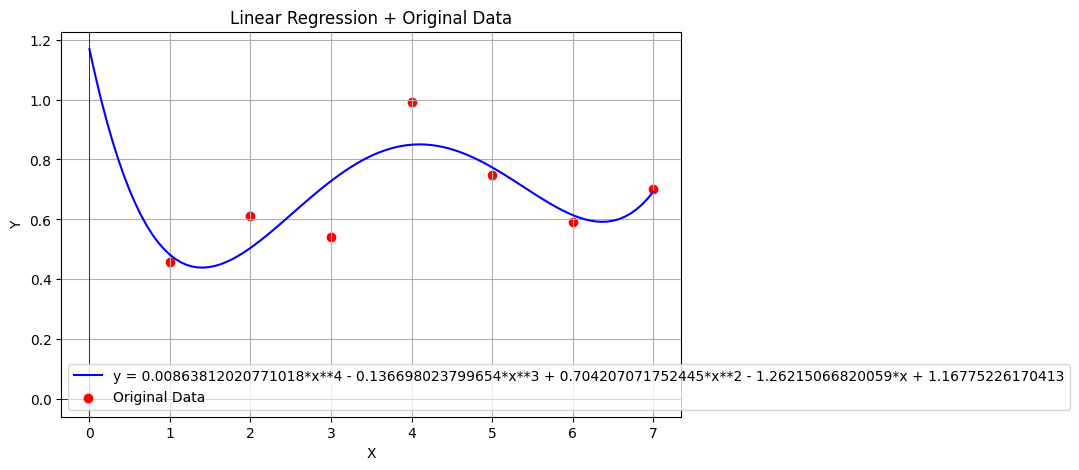

In [ ]:
import xgboost as xgb
def train_xgboost(df, target_column , T=0.2 , D =2, LR=0.1):
    # מחלק את הנתונים למשתנים (X) ועמודת מטרה (y)
    # הסרת כל עמודות datetime באופן אוטומטי
    X = df.drop(columns=[target_column])
    X = X.select_dtypes(exclude=['datetime64[ns]'])

    y = df[target_column]

    # המרת עמודת המטרה (y) למספרים באמצעות LabelEncoder
    target_encoder = LabelEncoder()
    y_encoded = target_encoder.fit_transform(y)

    # המרת משתנים קטגוריאליים במאפיינים (X) למספרים
    le = LabelEncoder()
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = le.fit_transform(X[col])

    # מחלק את הנתונים לאימון ובדיקת המודל
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=T, random_state=42)

    # יצירת מודל XGBoost
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        n_estimators=300,
        max_depth=D,
        learning_rate=LR,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=1,
        reg_lambda=1,
        random_state=42,
        use_label_encoder=False
    )

    # אימון המודל
    model.fit(X_train, y_train)

    # חיזוי על קבוצת הבדיקה
    y_pred = model.predict(X_test)

    # חישוב דיוק המודל
    accuracy = accuracy_score(y_test, y_pred)
    #print(f'Accuracy: {accuracy}')

    # הערכת המודל
    #evulate_modle(model, y_test, y_pred, target_encoder)

    # יצירת דוח
    #create_report(df, y_test, y_pred, target_encoder)

    return model , accuracy


# פונקציה להערכת המודל
def evulate_modle(model, yT, yP, target_encoder):
    # המרת הערכים חזרה לשמות המקוריים
    yT_original = target_encoder.inverse_transform(yT)
    yP_original = target_encoder.inverse_transform(yP)

    # חישוב דיוק, recall, precision, f1-score
    print("\nClassification Report:")
    print(classification_report(yT_original, yP_original))

    # מטריצת בלבול (Confusion Matrix)
    print("\nConfusion Matrix:")
    cm = confusion_matrix(yT_original, yP_original)
    print(cm)

    # הצגת מטריצת בלבול בצורה גרפית
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_,
                yticklabels=target_encoder.classes_)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


# פונקציה ליצירת דוח אודות המודל
def create_report(df, yT, yP, target_encoder):
    # מספר התצפיות הכולל
    total = len(df)

    # המרת הערכים חזרה לשמות המקוריים
    yT_original = target_encoder.inverse_transform(yT)
    yP_original = target_encoder.inverse_transform(yP)

    # חישוב דיוק המודל
    accuracy = accuracy_score(yT_original, yP_original)

    # הצגת הדוח
    print("\nModel Evaluation Report:")
    print(f"Total Observations: {total}")
    print(f"Accuracy: {accuracy}")

    # הצגת המידע על כל אחת מהקטגוריות
    print("\nDetailed Classification Report:")
    class_report = classification_report(yT_original, yP_original, output_dict=True)
    df_report = pd.DataFrame(class_report).transpose()

    # שמירת הדוח כקובץ CSV
    df_report.to_csv('Reports/XG_boost/Report_XGBoost.csv')


accuracy_for_reg = {}
acc_ = {}
# דוגמה לשימוש
# df - הנתונים שלך
# target_column - שם עמודת המטרה
mon=0
for i in range(5,12):
    mon+=1
    LR = random.uniform(0.1,5)
    TestSplit = random.uniform(0.1,0.3)
    model , acc = train_xgboost(df=df, target_column='Severity' , T=TestSplit , D=i,LR=LR)
    print(f'T = {TestSplit} , LR = {LR} , depth = {i} , Accuracy = {acc}')
    acc_[mon] = {"accuracy": acc, "T": TestSplit, "depth": i, "LR": LR}
    accuracy_for_reg[mon] = acc

# מציאת התוצאה הטובה ביותר
best_key = max(acc_, key=lambda k: acc_[k]['accuracy'])
best_result = acc_[best_key]

print(f"\n🔥 התוצאה הטובה ביותר:")
print(f"Index: {best_key}")
print(f"Accuracy: {best_result['accuracy']}")
print(f"TestSplit (T): {best_result['T']}")
print(f"Max Depth: {best_result['depth']}")
print(f"Learning Rate: {best_result['LR']}")


print(f'depth = 15 , accuracy = {Acc}')
fx=reg_accuracy_by_numpy(acc_dict=accuracy_for_reg,deg=4)
draw_fx(fx=fx,acc_dict=accuracy_for_reg)


# **model 2 - target impact (attack)**



In [ ]:
print(f'model - 2')
from catboost import Pool
current_F_impact = ['Impact','Title','Severity.1','Supersedes','Reboot','CVEs','Affected Component','Component KB']
currect_frame_impact = df_proccess[current_F_impact]
df_0_impact = currect_frame_impact.copy()

test = 0.443251
i=156
D=6
features_2 = ['Title',
            'Severity.1',
             'Supersedes',
             'Reboot',
             'CVEs',
             'Affected Component',
             'Component KB']

model - 2


In [ ]:
df_0_impact

,Impact,Title,Severity.1,Supersedes,Reboot,CVEs,Affected Component,Component KB
0,Remote Code Execution,Vulnerabilities in Microsoft XML Core Services...,Critical,MS07-042[936021],Maybe,"CVE-2007-0099,CVE-2008-4029,CVE-2008-4033",Microsoft XML Core Services 3.0,955069
1,Remote Code Execution,Vulnerabilities in Microsoft XML Core Services...,Critical,MS07-042[936021],Maybe,"CVE-2007-0099,CVE-2008-4029,CVE-2008-4033",Microsoft XML Core Services 3.0,955069
2,Remote Code Execution,Vulnerabilities in Microsoft XML Core Services...,Critical,MS07-042[936021],Maybe,"CVE-2007-0099,CVE-2008-4029,CVE-2008-4033",Microsoft XML Core Services 3.0,955069
3,Remote Code Execution,Vulnerabilities in Microsoft XML Core Services...,Critical,MS07-042[936021],Maybe,"CVE-2007-0099,CVE-2008-4029,CVE-2008-4033",Microsoft XML Core Services 3.0,955069
4,Remote Code Execution,Vulnerabilities in Microsoft XML Core Services...,Critical,MS07-042[936021],Maybe,"CVE-2007-0099,CVE-2008-4029,CVE-2008-4033",Microsoft XML Core Services 3.0,955069
...,...,...,...,...,...,...,...,...
23511,Spoofing,Erroneous VeriSign-Issued Digital Certificates...,Important,MS15-023[3034344],Yes,"CVE-2013-3128,CVE-2013-3200,CVE-2013-3879,CVE-...",Windows Internet Explorer 7,293818
23512,Spoofing,Erroneous VeriSign-Issued Digital Certificates...,Important,MS15-023[3034344],Yes,"CVE-2013-3128,CVE-2013-3200,CVE-2013-3879,CVE-...",Windows Internet Explorer 7,293818
23513,Spoofing,Erroneous VeriSign-Issued Digital Certificates...,Important,MS15-023[3034344],Yes,"CVE-2013-3128,CVE-2013-3200,CVE-2013-3879,CVE-...",Windows Internet Explorer 7,293818
23514,Spoofing,Erroneous VeriSign-Issued Digital Certificates...,Important,MS15-023[3034344],Yes,"CVE-2013-3128,CVE-2013-3200,CVE-2013-3879,CVE-...",Windows Internet Explorer 7,293818


In [ ]:
# בדיקה של שכיחות כל קטגוריה
counts = df_0_impact['Impact'].value_counts()
print(counts)
from collections import Counter

# ספירת שכיחות כל קטגוריה
counts = Counter(df_0_impact['Impact'])

# רשימה של קטגוריות נדירות (מופעים < 10)
rare_categories = [cat for cat, cnt in counts.items() if cnt < 10]
print("קטגוריות שאוחדו תחת 'Other':", rare_categories)

# יצירת העמודה המעובדת
y_processed = df_0_impact['Impact'].apply(lambda x: x if counts[x] >= 10 else 'Other')

# בדיקה של שכיחות הקטגוריות אחרי העיבוד
print(y_processed.value_counts())
print(y_processed)


Impact
Remote Code Execution      15697
Elevation of Privilege      4537
Information Disclosure      1258
Denial of Service           1126
Security Feature Bypass      509
Spoofing                     254
Tampering                     95
Remote code execution         28
Security Bypass                6
Not a Vulnerability            5
Defense in Depth               1
Name: count, dtype: int64
קטגוריות שאוחדו תחת 'Other': ['Not a Vulnerability', 'Defense in Depth', 'Security Bypass']
Impact
Remote Code Execution      15697
Elevation of Privilege      4537
Information Disclosure      1258
Denial of Service           1126
Security Feature Bypass      509
Spoofing                     254
Tampering                     95
Remote code execution         28
Other                         12
Name: count, dtype: int64
0        Remote Code Execution
1        Remote Code Execution
2        Remote Code Execution
3        Remote Code Execution
4        Remote Code Execution
                 ...       

In [ ]:
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

target = 'Impact'
features_2 = ['Title', 'Severity.1', 'Supersedes', 'Reboot', 'CVEs', 'Affected Component', 'Component KB']



X = df_0_impact[features_2]
y = y_processed

print(y.value_counts())

# כל הפיצ'רים הם קטגוריים (כפי שציינת)
cat_features = features_2

# חלוקה ל train ו test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test, random_state=42, stratify=y)

# יצירת מודל - למשל Classifier
model = CatBoostClassifier(
    iterations=156,  # לדוגמה, כמו שהגדרת ב-D
    depth=D,
    learning_rate=0.1,  # תוכל לשנות או להתאים
    verbose=100,
    cat_features=cat_features,
    random_seed=42
)

# אימון
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=20, use_best_model=True)

# חיזוי ובדיקה
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# אפשר להוסיף מדדים נוספים כמו F1 אם תרצה
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")


Impact
Remote Code Execution      15697
Elevation of Privilege      4537
Information Disclosure      1258
Denial of Service           1126
Security Feature Bypass      509
Spoofing                     254
Tampering                     95
Remote code execution         28
Other                         12
Name: count, dtype: int64
0:	learn: 1.5123548	test: 1.4848856	best: 1.4848856 (0)	total: 454ms	remaining: 1m 10s
100:	learn: 0.0814317	test: 0.0210643	best: 0.0210643 (100)	total: 35.1s	remaining: 19.1s
155:	learn: 0.0749636	test: 0.0183140	best: 0.0183140 (155)	total: 54.4s	remaining: 0us

bestTest = 0.01831399443
bestIteration = 155

Accuracy: 0.9952
F1 Score: 0.9950


In [ ]:
# Imports
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode categorical features
X_encoded = X.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtype=='object' else col)
y_encoded = LabelEncoder().fit_transform(y)

# חלוקה ל train/test (לשימוש ב-optuna נוכל להשתמש ב-cross-validation)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded)

# ============================
# Define Optuna objective
# ============================
def objective(trial):
    # Hyperparameters to tune
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 6, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 5)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 3)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Use 3-fold cross-validation
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

# ============================
# Create and run study
# ============================
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)  # running 10 times

# ============================
# Best parameters
# ============================
print("Best accuracy:", study.best_value)
print("Best parameters:", study.best_params)

# ============================
# Train final model with best params
# ============================
best_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print("Test Accuracy with best RF:", accuracy_score(y_test, y_pred))


[I 2025-08-13 14:00:43,933] A new study created in memory with name: no-name-bf12ad75-09a4-4adc-9d11-5079b861e4d5
[I 2025-08-13 14:00:58,370] Trial 0 finished with value: 0.9806506485222198 and parameters: {'n_estimators': 292, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.9806506485222198.
[I 2025-08-13 14:01:09,243] Trial 1 finished with value: 0.9289815011694662 and parameters: {'n_estimators': 411, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9806506485222198.
[I 2025-08-13 14:01:15,683] Trial 2 finished with value: 0.9278474732440287 and parameters: {'n_estimators': 269, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.9806506485222198.
[I 2025-08-13 14:01:29,190] Trial 3 finished with value: 0.9737047274789141 and parameters: {'n_estimators': 478, 'max_depth': 17, 'm

Best accuracy: 0.9806506485222198
Best parameters: {'n_estimators': 292, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}
Test Accuracy with best RF: 0.9873498458594664


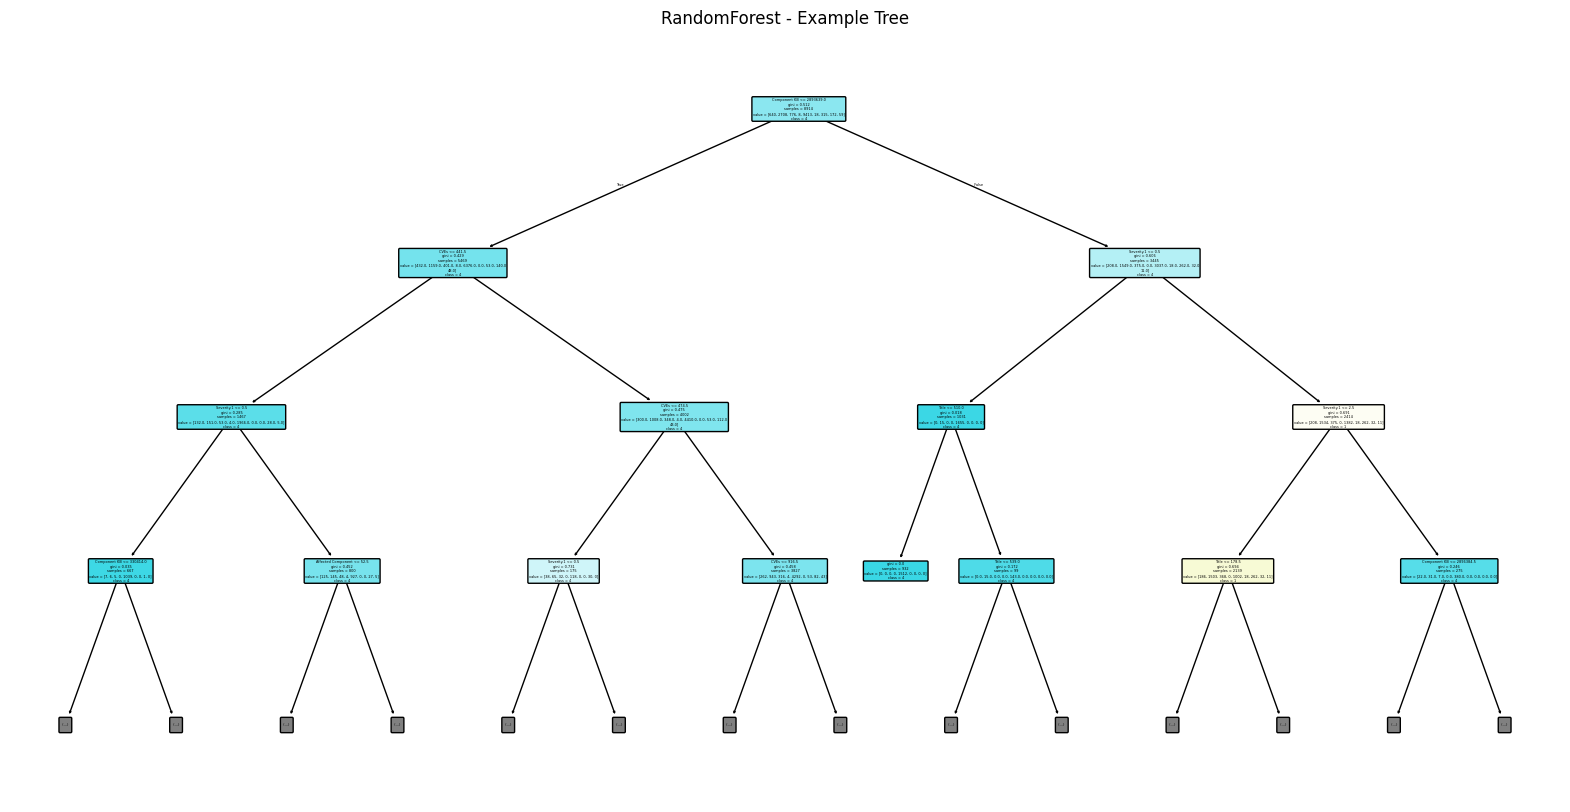

In [ ]:

tree_to_plot = best_model.estimators_[0]  # העץ הראשון

# ציור העץ
plt.figure(figsize=(20,10))
plot_tree(
    tree_to_plot,
    feature_names=X.columns,      # שמות הפיצ'רים
    class_names=[str(c) for c in best_model.classes_],  # שמות הקטגוריות
    filled=True,                  # צבעים לפי הקטגוריות
    rounded=True,
    max_depth=3                   # להראות רק 3 רמות ראשונות (לנוחות)
)
plt.title("RandomForest - Example Tree")
plt.show()


{1: 0.9807, 2: 0.929, 3: 0.9278, 4: 0.9737, 5: 0.9322, 6: 0.9579, 7: 0.9098, 8: 0.9081, 9: 0.9279, 10: 0.8865}


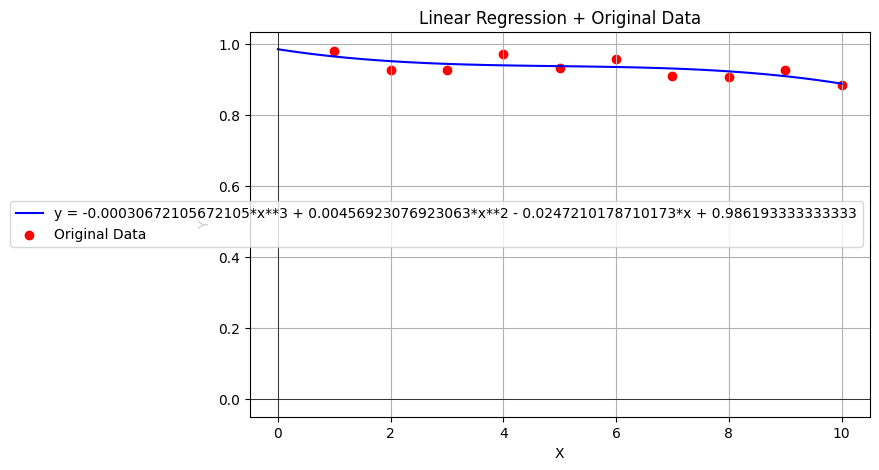

In [ ]:
# נניח שיש לנו רשימה עם ערכי דיוק מהלוג
trial_values = [
    0.9806506485222198,
    0.9289815011694662,
    0.9278474732440287,
    0.9737047274789141,
    0.9321709547097597,
    0.9578992132681267,
    0.9098447799277057,
    0.9081437380395491,
    0.9279183499893685,
    0.8865263307108938
]


rf_acc_dict = {i+1: round(val,4) for i, val in enumerate(trial_values)}
print(rf_acc_dict)



fx = reg_accuracy_by_numpy(acc_dict=rf_acc_dict, deg=3)
draw_fx(fx,acc_dict=rf_acc_dict)

In [ ]:
model.save_model('impactModel_cat.cbm')

In [ ]:
m1_impact = model.load_model('impactModel_cat.cbm')
df_0_impact.to_csv('impactFeatures_cat.csv')
m1_impact.feature_names_


['Title',
 'Severity.1',
 'Supersedes',
 'Reboot',
 'CVEs',
 'Affected Component',
 'Component KB']

# **HTML attractive model**

In [ ]:
from google.colab import files


MyGlobalModel = None

cssName = "@import url('https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css');"
def runApp(df, features_, model):
    global MyGlobalModel , cssName
    MyGlobalModel = model

    # בונים את האינפוטים - כל תכונה היא Dropdown עם הערכים הייחודיים
    inputs = []
    for feature in features_:
        df[feature] = df[feature].astype(str)
        unique_values = df[feature].dropna().unique()
        options = list(map(str, unique_values))
        inputs.append(gr.Dropdown(choices=options, label=feature))

    def predict(*selected_values):
        # המודל מצפה לרשימת ערכים כקלט
        selected = [val if val is not None else "None" for val in selected_values]
        prediction = MyGlobalModel.predict([selected])
        result = prediction[0] if isinstance(prediction, (list, np.ndarray)) else prediction
        return f"Model Prediction: {result}"

    try:
      with open(f"/content/{cssName}", "r") as f:
        css_str = f.read()
    except Exception as e:
      print(f"Error reading CSS file: {e}")
      css_str = cssName

    # יוצרים ממשק עם כל ה-dropdowns + כפתור "Send" שמפעיל את הפונקציה predict
    iface = gr.Interface(
            fn=predict,
            inputs=inputs,
            outputs="text",
            title="Prediction Microsoft Security",
            description="Please choose options from the dropdown menus and press 'Send' to receive the model's prediction.",
            css=css_str
    )
    html_code = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>My Gradio App</title>
    </head>
    <body>
        <h2>Gradio Prediction App</h2>
        <iframe src={iface.share_url} width="100%" height="800px"></iframe>
    </body>
    </html>
    """
    iface.launch( share = True)
    with open("my_app.html", "w") as f:
      f.write(html_code)
    #files.download("my_app.html")
    return html_code
# דוגמה לשימוש
# df = ... טען את ה-DataFrame שלך
# features = [...] רשימת התכונות
# model = CatBoostClassifier() + אימון או טעינה של מודל
html_code = runApp(df_0, features, catMod)


Error reading CSS file: [Errno 2] No such file or directory: "/content/@import url('https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css');"
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://84b1df068c91d4e287.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



# **Sql - Code**
- the code cant running , not support in cloud
- video of sql in git


In [ ]:
from sqlalchemy import create_engine, text , inspect

# If the tables already exist:
# Using 'if_exists="replace"' in df.to_sql will drop the existing table and recreate it with new data.
# This means every time you run the function with the same table name, the old table is completely replaced.
#





def get_engine(schema_name='project_database', user='root', password='9192939495', host='localhost', port='3306'):
    """
    מחזירה אובייקט engine לפי פרטי חיבור שהוזנו.
    אם schema_name לא מוגדר, תוחזר התחברות רק לשרת ללא בסיס נתונים.
    """
    if schema_name:
        connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{schema_name}"
    else:
        connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/"
    return create_engine(connection_string, echo=False)

def save_excel_to_mysql(path,table_name ,schema_name='project_database', password='9192939495' , user='root'):
    print(f".... 🛠️ Creating schema '{schema_name}' in table '{table_name}' for user '{user}' 👤✅")

    schema_name = schema_name
    table_name = table_name
    mysql_user = user
    mysql_password = password
    mysql_host = 'localhost'
    mysql_port = '3306'

    # קריאת הקובץ
    try:
        excel_path = path
        df = pd.read_excel(excel_path)
        print(f"✅ Excel file loaded successfully from: {excel_path}")
    except Exception as e:
        print("ERROR : cant read - ", e)
        df=path
        print('💮your path is instance of dataframe .')

        pass

    # החלפת רווחים בנקודתיים ושינויים בשמות העמודות
    def clean_column_name(col_name):
        return col_name.replace(' ', '_').replace('.', 'POINT')

    df.rename(columns=clean_column_name, inplace=True)

    # יצירת חיבור למנוע MySQL דרך SQLAlchemy
    connection_string = f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}:{mysql_port}/"
    engine = create_engine(connection_string, echo=False)

    # יצירת הסכימה (Database) אם לא קיימת
    try:
        with engine.connect() as conn:
            conn.execute(text(f"CREATE DATABASE IF NOT EXISTS `{schema_name}` DEFAULT CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci;"))
            print(f"🍻 database - {schema_name} created . ")
    except Exception as e:
        print("ERROR : cant create database - ", e)
        return

    # מחברים מחדש עם הסכימה (database) כדי לכתוב את הטבלה
    connection_string_db = f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}:{mysql_port}/{schema_name}"
    engine_db = create_engine(connection_string_db, echo=False)

    # שמירת הנתונים לטבלה - אם הטבלה קיימת, מוחקים ומחליפים (replace)
    try:
        df.to_sql(name=table_name, con=engine_db, if_exists='replace', index=False)
        print(f"✅ Table '{table_name}' was successfully saved in schema '{schema_name}'. 💾🎉")
    except Exception as e:
        print("שגיאה בשמירת הטבלה:", e)

def get_preimr_code_by_table_name(table_name, schema_name='project_database', user='root', password='9192939495',printing = False):
    try:
        engine = get_engine(schema_name=schema_name, user=user, password=password)
        inspector = inspect(engine)

        # כל העמודות
        columns = inspector.get_columns(table_name)
        col_names = [col['name'] for col in columns]

        # המפתח הראשי (אם קיים)
        pk_info = inspector.get_pk_constraint(table_name)
        pk_columns = pk_info.get('constrained_columns', [])
        if printing:
            print(f"📌 Columns in table '{table_name}': {col_names}")
            print(f"🔑 Primary key(s): {pk_columns}")

        return {'columns': col_names, 'pk': pk_columns}

    except Exception as e:
        print("⚠️ Error getting primary key or columns:", e)
        return None



def drop_col_by_primery(table_name, primery_kay={'ID': 1}, schema_name='project_database',printing = False, user='root', password='9192939495'):
    engine = get_engine(schema_name=schema_name, user=user, password=password)
    dels = None
    pk = get_preimr_code_by_table_name(table_name=table_name,schema_name=schema_name)
    if len(pk['pk'])==0 :
        return False
    try:
        col_name, val = list(primery_kay.items())[0]
        with engine.begin() as conn:  # 'begin' פותח טרנזקציה עם commit אוטומטי בסיום
            delete_stmt = text(f"DELETE FROM `{table_name}` WHERE `{col_name}` = :val")
            result = conn.execute(delete_stmt, {"val": val})
            if result.rowcount==1:
                dels=True
            elif result.rowcount==0:
                dels = False
            if printing:
                print(f"🗑️ Deleted {result.rowcount} row(s) from '{table_name}' where {col_name}={val}")
        return  dels
    except Exception as e:
        print("⚠️ Error deleting by primary key:", e)


def set_pk(table_name ,schema_name='project_database', pk_name='ID', user='root', password='9192939495'):
    try:
        engine = get_engine(schema_name=schema_name, user=user, password=password)
        with engine.connect() as conn:
            inspector = inspect(engine)


            dict_primary = get_preimr_code_by_table_name(table_name=table_name, schema_name=schema_name)
            current_pks = dict_primary['pk']


            if current_pks:
                print(f"✅ Table '{table_name}' already has a primary key defined: {current_pks} – no action taken.")
                return

            # חיפוש שם עמודה ייחודי להוספה, לדוגמה set_id_pk1, set_id_pk2 ...
            existing_columns = [col['name'] for col in inspector.get_columns(table_name)]
            new_col_name = pk_name
            while new_col_name in existing_columns:
                new_col_name = pk_name

            # הוספת עמודה חדשה מסוג INT AUTO_INCREMENT NOT NULL
            conn.execute(text(f"""
                ALTER TABLE `{table_name}`
                ADD COLUMN `{new_col_name}` INT NOT NULL AUTO_INCREMENT UNIQUE
            """))

            # הגדרת העמודה החדשה כמפתח ראשי
            conn.execute(text(f"""
                ALTER TABLE `{table_name}`
                ADD PRIMARY KEY (`{new_col_name}`)
            """))

            print(f"✅ Added new primary key '{new_col_name}' to table '{table_name}'")

    except Exception as e:
        print(f"❌ Error setting primary key: {e}")



def get_col_info(table_name, col_name, schema_name='project_database', user='root', password='9192939495'):
    try:
        engine = get_engine(schema_name=schema_name, user=user, password=password)
        with engine.connect() as conn:
            df = pd.read_sql_table(table_name, con=engine)

        if col_name not in df.columns:
            raise ValueError(f"Column '{col_name}' not found in table '{table_name}'.")

        col_data = df[col_name]

        stats = {
            "Data Type": str(col_data.dtype),
            "Number of Nulls": col_data.isnull().sum(),
            "Number of Unique Values": col_data.nunique()
        }

        # עמודות מספריות – הוספת סטטיסטיקות
        if pd.api.types.is_numeric_dtype(col_data):
            desc = col_data.describe()
            stats.update({
                "Count": desc.get("count", None),
                "Mean": desc.get("mean", None),
                "Standard Deviation": desc.get("std", None),
                "Minimum": desc.get("min", None),
                "25th Percentile": desc.get("25%", None),
                "50th Percentile (Median)": desc.get("50%", None),
                "75th Percentile": desc.get("75%", None),
                "Maximum": desc.get("max", None)
            })
        else:
            # קטגורית – הצגת עד 10 ערכים ייחודיים
            unique_vals = col_data.dropna().unique()[:3]
            stats["Top 10 Unique Values"] = list(unique_vals)

        # הפיכת הסטטיסטיקה לסדרה
        stats_series = pd.Series(stats, name=col_name)


        return stats_series, col_data

    except Exception as e:
        print("⚠️ Error getting column info:", e)
        return None


def get_row_info(table_name, id_value, id_column='ID', schema_name='project_database'):
    try:
        engine = get_engine(schema_name=schema_name)
        with engine.connect() as conn:
            df = pd.read_sql_table(table_name, con=engine)

        if id_column not in df.columns:
            raise ValueError(f"⚠️ Column '{id_column}' not found in table '{table_name}'.")

        # איתור השורה לפי הערך ב-id_column
        row = df[df[id_column] == id_value]

        if row.empty:
            raise ValueError(f"⚠️ Row with {id_column} = {id_value} not found in table '{table_name}'.")

        # ניקח רק את השורה הראשונה אם יש יותר מאחת עם אותו ID

        return row
    except Exception as e:
        print("⚠️ Error getting row info:", e)
        return None
def is_exist_schema(schema_name,user='root', password='9192939495'):
    try:
        # התחברות לשרת MySQL ללא סכימה מסוימת
        #engine = create_engine(f'mysql+pymysql://{user}:{password}@{host}:{port}')
        engine = get_engine()
        with engine.connect() as conn:
            result = conn.execute(text("SHOW DATABASES;"))
            databases = [row[0] for row in result]

        if schema_name in databases:
            return True
        else:
            raise False

    except Exception as e:
        raise Exception(f"שגיאה בבדיקת הסכימה: {e}")
def is_exist_table(schema_name,table_name):
    try:
        # התחברות לשרת MySQL ללא סכימה מסוימת
        # בודק אם הטבלה קיימת
        engine = get_engine()
        query = """
                SELECT COUNT(*)
                FROM information_schema.tables
                WHERE table_schema = :schema_name
                  AND table_name = :table_name
                LIMIT 1;
            """
        with engine.connect() as conn:
            result = conn.execute(text(query), {
                'schema_name': schema_name,
                'table_name': table_name
            })
            count = result.scalar()
            return count > 0

    except Exception as e:
        raise Exception(f"שגיאה בבדיקת הסכימה: {e}")

def add_row_by_pk(schema_name, table_name, pk_columns, column_add):
    engine = get_engine(schema_name=schema_name)

    # נקי את שמות המפתחות במילון column_add
    clean_column_add = {clean_column_name(k): v for k, v in column_add.items()}

    # בדיקת קיום שורה עם ערכי מפתח ראשי
    where_conditions = []
    where_params = {}

    for key in pk_columns:
        clean_key = clean_column_name(key)
        if clean_key not in clean_column_add:
            print(f"❌ Missing PK column '{clean_key}' in column_add!")
            return
        where_conditions.append(f"`{clean_key}` = :{clean_key}")
        where_params[clean_key] = clean_column_add[clean_key]

    where_clause = " AND ".join(where_conditions)
    check_sql = f"SELECT COUNT(*) FROM `{table_name}` WHERE {where_clause};"

    try:
        with engine.connect() as conn:
            count = conn.execute(text(check_sql), where_params).scalar()
            if count > 0:
                print(f"⚠️ Row with PK {where_params} already exists. No insert done.")
                return

        # הכנת INSERT
        cols = list(clean_column_add.keys())
        cols_str = ", ".join([f"`{col}`" for col in cols])
        placeholders = ", ".join([f":{col}" for col in cols])
        insert_sql = f"INSERT INTO `{table_name}` ({cols_str}) VALUES ({placeholders});"

        with engine.begin() as conn:
            conn.execute(text(insert_sql), clean_column_add)
            print(f"✅ Row inserted into `{table_name}` successfully.")

    except Exception as e:
        print(f"❌ Error: {e}")

def clean_column_name(col_name):
    return col_name.replace(' ', '_').replace('.', 'POINT')

def get_col_types(table_name,schema_name = 'project_database'):
    try:
        engine = get_engine()
        full_table_name = f"`{schema_name}`.`{table_name}`" if schema_name else f"`{table_name}`"

        query = text(f"SHOW COLUMNS FROM {full_table_name};")

        with engine.connect() as conn:
            result = conn.execute(query)
            columns_info = result.fetchall()

        # columns_info: [(Field, Type, Null, Key, Default, Extra), ...]
        col_types = {row[0]: row[1] for row in columns_info}
        return col_types

    except Exception as e:
        raise Exception(f"שגיאה בקבלת סוגי עמודות: {e}")


# **target - impact (attack)**


In [ ]:
m1_impact

In [ ]:
import gradio as gr
import numpy as np

index_ans = None
prob_ans = None
def run_catboost_gradio(df, model, features, cssName=""):
    """
    df - DataFrame עם הפיצ'רים לממשק (לטובת הרשימות dropdown)
    model - מודל CatBoost מאומן
    features - רשימת הפיצ'רים הסדר שהמודל מצפה להם
    cssName - optional path to css file
    """
    global index_ans, prob_ans

    # לוודא שכל הפיצ'רים מחרוזות (כמו באימון)
    for feat in features:
        df[feat] = df[feat].astype(str)

    # בונים רשימות אפשרויות ל-dropdown לכל פיצ'ר
    inputs = []
    for feat in features:
        unique_vals = sorted(df[feat].dropna().unique())
        inputs.append(gr.Dropdown(choices=unique_vals, label=feat, value=unique_vals[0]))

    def predict(*selected_values):
      try:
        # כל הערכים שנבחרו הם מחרוזות
        input_data = list(selected_values)
        result_str = ""

        if hasattr(model, 'predict_proba'):
            # חישוב ההסתברויות לכל הכיתות
            pred_prob = model.predict_proba([input_data])[0]
            # מציאת האינדקס עם ההסתברות הגבוהה ביותר
            max_index = np.argmax(pred_prob)
            # הכיתה עם ההסתברות הגבוהה ביותר
            max_class = model.classes_[max_index]
            max_prob = pred_prob[max_index]
            result_str = f"Prediction: {max_class}\nProbability: {max_prob:.4f}"
        else:
            # אם אין predict_proba, מחזירים את התחזית הרגילה
            prediction = model.predict([input_data])
            result_str = f"Prediction: {prediction[0]}"
        index_ans = model.classes_
        prob_ans = model.predict_proba([input_data])
        return result_str

      except Exception as e:
        return f"Error during prediction: {e}"



    # טעינת CSS במידה וקיים
    css_str = ""
    if cssName:
        try:
            with open(cssName, "r") as f:
                css_str = f.read()
        except Exception as e:
            print(f"Error reading CSS file: {e}")

    iface = gr.Interface(
        fn=predict,
        inputs=inputs,
        outputs="text",
        title="CatBoost Impact Prediction",
        description="בחר ערכים מכל הרשימות ולחץ Send כדי לקבל חיזוי.",
        css=css_str
    )

    iface.launch(share=True)


run_catboost_gradio(df_filtered, m1_impact, features_2)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://72a8f4bfc89cc4b783.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
